<a href="https://colab.research.google.com/github/abdoyanes/Point-Cloud-Data_analysis/blob/main/ET_PET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ║           NOTEBOOK 5 — VALIDATION & CROSS-PRODUCT COMPARISON               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 6 of your Colab notebook.
# This cell is FULLY SELF-CONTAINED — safe to run after kernel restart.

# ── 5.0  Guaranteed session bootstrap ────────────────────────────────────────
import ee, os, json, glob, warnings
import pandas as pd
import numpy as np
from scipy import stats
warnings.filterwarnings("ignore")

# -- GEE initialisation -------------------------------------------------------
try:
    ee.Number(1).getInfo()          # quick ping
except Exception:
    ee.Initialize()
    print("GEE re-initialised")

# -- Core constants -----------------------------------------------------------
START_YEAR = 2001
END_YEAR   = 2023
START_DATE = f"{START_YEAR}-01-01"
END_DATE   = f"{END_YEAR}-12-31"
years      = list(range(START_YEAR, END_YEAR + 1))
OUTPUT_DIR = "/content/drive/MyDrive/ET_WhiteNile_Analysis"

# -- AOI geometry -------------------------------------------------------------
# Try (1) live session variable, (2) uploaded shapefile, (3) GAUL fallback
try:
    # aoi_geometry should already be an ee.Geometry from previous cells.
    # Explicitly ensure it's an ee.Geometry object and apply robustness steps
    aoi_geometry = ee.Geometry(aoi_geometry).buffer(1).simplify(100).transform('EPSG:4326', 1)
    print("✅ aoi_geometry: already in session (robustness applied)")
except (NameError, AttributeError, ee.EEException):
    # Priority 1: GEE personal asset
    try:
        _asset       = 'projects/ee-abdoyanes2016/assets/White_NILe_State'
        AOI          = ee.FeatureCollection(_asset)
        # Apply robustness steps for newly loaded AOI
        # Use AOI.geometry() to get a single geometry from the FeatureCollection
        aoi_geometry = ee.Geometry(AOI.geometry()).buffer(1).simplify(100).transform('EPSG:4326', 1)
        aoi_geometry.bounds().getInfo()
        print(f"✅ aoi_geometry: GEE asset ({_asset})")
    except Exception as _ea:
        print(f"⚠️  GEE asset failed ({_ea}) — trying shapefile...")
        _shp = (glob.glob("/tmp/*/s_area.shp") +
                glob.glob("/tmp/s_area.shp") +
                glob.glob("/content/s_area.shp") +
                glob.glob("/content/drive/MyDrive/**/s_area.shp", recursive=True))
        if _shp:
            import geopandas as gpd
            _gdf         = gpd.read_file(_shp[0]).to_crs("EPSG:4326")
            AOI          = ee.FeatureCollection(json.loads(_gdf.to_json()))
            # Apply robustness steps for newly loaded AOI
            # Use AOI.geometry() to get a single geometry from the FeatureCollection
            aoi_geometry = ee.Geometry(AOI.geometry()).buffer(1).simplify(100).transform('EPSG:4326', 1)
            print(f"✅ aoi_geometry: shapefile ({_shp[0]})")
        else:
            _gaul        = ee.FeatureCollection("FAO/GAUL/2015/level1")
            AOI          = _gaul.filter(ee.Filter.And(
                               ee.Filter.eq("ADM0_NAME", "Sudan"),
                               ee.Filter.eq("ADM1_NAME", "White Nile")))
            # Apply robustness steps for newly loaded AOI
            # Use AOI.geometry() to get a single geometry from the FeatureCollection
            aoi_geometry = ee.Geometry(AOI.geometry()).buffer(1).simplify(100).transform('EPSG:4326', 1)
            print("✅ aoi_geometry: FAO GAUL fallback")

# -- MOD16 collection ---------------------------------------------------------
def _qc_scale(img):
    qc  = img.select("ET_QC")
    ok  = qc.bitwiseAnd(3).lte(1)
    et  = img.select("ET").multiply(0.1).updateMask(ok).rename("ET_mm")
    pet = img.select("PET").multiply(0.1).updateMask(ok).rename("PET_mm")
    ef  = et.divide(pet).rename("EF")
    return img.addBands(et).addBands(pet).addBands(ef).copyProperties(
               img, ["system:time_start"])

MOD16 = (ee.ImageCollection("MODIS/061/MOD16A2GF")
           .filterDate(START_DATE, END_DATE)
           .filterBounds(aoi_geometry)
           .map(_qc_scale))

# -- Load saved time-series CSVs (preferred — avoids recomputing GEE calls) --
_t4 = f"{OUTPUT_DIR}/tables/T4_Annual_ET_TimeSeries.csv"
_t7 = f"{OUTPUT_DIR}/tables/T7_Annual_WaterBalance_TimeSeries.csv"

if os.path.exists(_t4) and os.path.exists(_t7):
    df_timeseries = pd.read_csv(_t4)
    df_wb_ts      = pd.read_csv(_t7)
    print(f"✅ T4 loaded: {len(df_timeseries)} rows")
    print(f"✅ T7 loaded: {len(df_wb_ts)} rows")
else:
    df_timeseries = pd.DataFrame()
    df_wb_ts      = pd.DataFrame(columns=["Year","Precip_mm","ET_mm"])
    print("⚠️  T4/T7 CSVs not found on Drive — recomputing from GEE...")
    print(f"   Expected at: {OUTPUT_DIR}/tables/")

    # Recompute annual regional ET + P from GEE if CSVs are missing
    _rows = []
    for _yr in years:
        _et = (MOD16.filter(ee.Filter.calendarRange(_yr, _yr, "year"))
                    .select("ET_mm").mean().multiply(46)
                    .reduceRegion(reducer=ee.Reducer.mean(),
                                  geometry=aoi_geometry,
                                  scale=1000, maxPixels=1e10,
                                  bestEffort=True).getInfo())
        _p  = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
                  .filterDate(f"{_yr}-01-01", f"{_yr}-12-31")
                  .filterBounds(aoi_geometry).sum()
                  .reduceRegion(reducer=ee.Reducer.mean(),
                                geometry=aoi_geometry,
                                scale=5000, maxPixels=1e10,
                                bestEffort=True).getInfo())
        _rows.append({
            "Year":       _yr,
            "ET_mm":      round(_et.get("ET_mm", 0) or 0, 1),
            "Precip_mm":  round(_p.get("precipitation", 0) or 0, 1),
        })
        print(f"  {_yr}: ET={_rows[-1]['ET_mm']} mm | P={_rows[-1]['Precip_mm']} mm")

    df_wb_ts      = pd.DataFrame(_rows)
    df_timeseries = df_wb_ts.copy()

print("\n✅ Session bootstrap complete — proceeding to validation")

# ── 5.1  NDVI–ET Consistency Check (MOD13A2) ─────────────────────────────────
# ET and NDVI should be positively correlated in vegetated classes.
# MODIS MOD13A2: 1 km, 16-day NDVI composite. Scale factor = 0.0001.
NDVI_col = (ee.ImageCollection("MODIS/061/MOD13A2")
              .filterDate(START_DATE, END_DATE)
              .filterBounds(aoi_geometry)
              .select("NDVI")
              .map(lambda img: img.multiply(0.0001)
                                  .clip(aoi_geometry) # Apply clip to the annual mean image
                                  .copyProperties(img, ["system:time_start"]))) # Removed clip from map

# Annual mean NDVI per year
ndvi_ts_rows = []
for year in years:
    ndvi_yr = (NDVI_col
                 .filter(ee.Filter.calendarRange(year, year, "year"))
                 .mean()
                 .reduceRegion(
                     reducer=ee.Reducer.mean(),
                     geometry=aoi_geometry, # Changed from aoi_geometry.buffer(1)
                     scale=1000,
                     maxPixels=1e10,
                     bestEffort=True
                 ).getInfo())
    ndvi_ts_rows.append({"Year": year,
                          "NDVI": round(ndvi_yr.get("NDVI", 0) or 0, 4)})

df_ndvi_ts = pd.DataFrame(ndvi_ts_rows)
df_valid   = df_wb_ts.merge(df_ndvi_ts, on="Year")

# Pearson correlation: ET vs NDVI
_et_clean   = df_valid["ET_mm"].dropna()
_ndvi_clean = df_valid["NDVI"].dropna()
_common_idx = _et_clean.index.intersection(_ndvi_clean.index)

r_et_ndvi, p_et_ndvi = stats.pearsonr(
    _et_clean.loc[_common_idx],
    _ndvi_clean.loc[_common_idx]
)
print(f"🔬 ET–NDVI Correlation (regional annual means):")
print(f"   Pearson r = {r_et_ndvi:.3f} | p = {p_et_ndvi:.4f}")
if r_et_ndvi > 0.6 and p_et_ndvi < 0.05:
    print("   ✅ Strong positive ET–NDVI coupling — product is physically consistent")
elif r_et_ndvi > 0.3:
    print("   ⚠️  Moderate ET–NDVI coupling — check cloud contamination in wet season")
else:
    print("   ❌ Weak ET–NDVI correlation — check LULC classification or QC filtering")

# ── 5.2  Water Balance Closure Check ─────────────────────────────────────────
print("\n🔬 Water Balance Closure Check (P – ET = ΔS + Q):")
print("   Q ≈ 10% of P (semi-arid Sudan estimate) | ΔS ≈ 0 (long-term mean)")

if df_wb_ts.empty or "Precip_mm" not in df_wb_ts.columns:
    print("   ⚠️  Skipped — water balance data not available")
    mean_closure_err = float("nan")
else:
    df_valid["Q_approx_mm"]      = df_valid["Precip_mm"] * 0.10
    df_valid["Closure_Error_mm"] = (df_valid["Precip_mm"]
                                     - df_valid["ET_mm"]
                                     - df_valid["Q_approx_mm"])
    df_valid["Closure_Error_pct"] = (
        df_valid["Closure_Error_mm"]
        / df_valid["Precip_mm"].replace(0, np.nan) * 100
    ).round(1)

    mean_closure_err = df_valid["Closure_Error_pct"].abs().mean()
    print(f"   Mean absolute closure error: {mean_closure_err:.1f}%")
    if mean_closure_err < 15:
        print("   ✅ Acceptable closure (<15%) — water balance internally consistent")
    elif mean_closure_err < 30:
        print("   ⚠️  Moderate closure error (15–30%) — review Q estimate or ET bias")
    else:
        print("   ❌ Large closure error (>30%) — investigate data quality")

# Save validation table
df_valid.to_csv(f"{OUTPUT_DIR}/tables/T8_Validation_NDVI_WaterBalance.csv", index=False)
print("\n💾 Saved: T8_Validation_NDVI_WaterBalance.csv")

# ── 5.3  FIGURE 5: Validation Dashboard ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Validation & Consistency Checks — White Nile State (2001–2023)",
    fontsize=14, fontweight="bold"
)

# Panel A: ET vs NDVI scatter
ax = axes[0, 0]
ax.scatter(df_valid["NDVI"], df_valid["ET_mm"],
           color="green", alpha=0.7, s=70, edgecolors="k", linewidths=0.5)
if len(df_valid) > 1:
    _m, _b = np.polyfit(df_valid["NDVI"].fillna(0), df_valid["ET_mm"].fillna(0), 1)
    _x = np.linspace(df_valid["NDVI"].min(), df_valid["NDVI"].max(), 50)
    ax.plot(_x, _m * _x + _b, "r-", linewidth=2,
            label=f"r = {r_et_ndvi:.3f}  p = {p_et_ndvi:.4f}")
ax.set_xlabel("Regional Mean NDVI", fontsize=11)
ax.set_ylabel("Regional Mean ET (mm/yr)", fontsize=11)
ax.set_title("A. ET vs NDVI Consistency", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel B: ET vs Precipitation scatter
ax = axes[0, 1]
if "Precip_mm" in df_valid.columns:
    _r_p, _p_p = stats.pearsonr(df_valid["Precip_mm"].fillna(0),
                                 df_valid["ET_mm"].fillna(0))
    ax.scatter(df_valid["Precip_mm"], df_valid["ET_mm"],
               color="blue", alpha=0.7, s=70, edgecolors="k", linewidths=0.5)
    _m2, _b2 = np.polyfit(df_valid["Precip_mm"].fillna(0),
                           df_valid["ET_mm"].fillna(0), 1)
    _x2 = np.linspace(df_valid["Precip_mm"].min(), df_valid["Precip_mm"].max(), 50)
    ax.plot(_x2, _m2 * _x2 + _b2, "r-", linewidth=2,
            label=f"r = {_r_p:.3f}  p = {_p_p:.4f}")
    _mx = max(df_valid["Precip_mm"].max(), df_valid["ET_mm"].max())
    ax.plot([0, _mx], [0, _mx], "k--", linewidth=1, alpha=0.5, label="ET = P line")
ax.set_xlabel("Annual Precipitation CHIRPS (mm)", fontsize=11)
ax.set_ylabel("Annual ET MOD16 (mm)", fontsize=11)
ax.set_title("B. ET vs Precipitation Coupling", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel C: Water balance closure error bar chart
ax = axes[1, 0]
if "Closure_Error_pct" in df_valid.columns:
    _cols = ["#2b83ba" if abs(v) < 15 else "#fdae61" if abs(v) < 30 else "#d7191c"
             for v in df_valid["Closure_Error_pct"]]
    ax.bar(df_valid["Year"], df_valid["Closure_Error_pct"],
           color=_cols, alpha=0.85, edgecolor="grey", linewidth=0.4)
    ax.axhline(0,   color="black",  linewidth=1)
    ax.axhline(15,  color="orange", linewidth=1, linestyle="--", label="±15% threshold")
    ax.axhline(-15, color="orange", linewidth=1, linestyle="--")
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Closure Error (% of P)", fontsize=11)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No closure data available",
            ha="center", va="center", transform=ax.transAxes, color="grey")
ax.set_title("C. Annual Water Balance Closure Error", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# Panel D: ET & NDVI dual-axis time series
ax  = axes[1, 1]
ax2 = ax.twinx()
l1, = ax.plot(df_valid["Year"],  df_valid["ET_mm"],
              "r-o", markersize=4, linewidth=2, label="ET (mm/yr)")
l2, = ax2.plot(df_valid["Year"], df_valid["NDVI"],
               "g--s", markersize=4, linewidth=2, label="NDVI")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Annual ET (mm)", fontsize=11, color="red")
ax2.set_ylabel("Regional Mean NDVI", fontsize=11, color="green")
ax.set_title("D. ET & NDVI Co-evolution (2001–2023)", fontweight="bold")
ax.legend(handles=[l1, l2], fontsize=9, loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/F5_Validation_Dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()

✅ aoi_geometry: already in session (robustness applied)
✅ T4 loaded: 184 rows
✅ T7 loaded: 23 rows

✅ Session bootstrap complete — proceeding to validation


EEException: Geometry.buffer: Can't buffer with a 0 error margin.

In [42]:
# @title Default title text
# ║         NOTEBOOK 0 — ENVIRONMENT SETUP & AUTHENTICATION                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 1 of your Colab notebook

# ── 0.1  Install required packages ──────────────────────────────────────────
!pip install geemap earthengine-api pymannkendall scipy statsmodels matplotlib \
             seaborn geopandas rasterio cartopy --quiet

# ── 0.2  Imports ─────────────────────────────────────────────────────────────
import ee
import geemap
import geemap.colormaps as cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pymannkendall as mk
import os
import warnings
warnings.filterwarnings('ignore')

# ── 0.3  Google Earth Engine Authentication ──────────────────────────────────
# This will open a browser window — sign in with your GEE-registered account
ee.Authenticate()
ee.Initialize(project='evapotranspiration-495110')  # ← Replace with your GEE project ID

# ── 0.4  Google Drive mount (for output export) ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Create local output directory (mirrors Drive folder)
OUTPUT_DIR = '/content/drive/MyDrive/ET_WhiteNile_Analysis'
os.makedirs(f'{OUTPUT_DIR}/maps',    exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/tables',  exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/plots',   exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/geotiff', exist_ok=True)

print("✅ Environment ready. Output folder:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environment ready. Output folder: /content/drive/MyDrive/ET_WhiteNile_Analysis


In [43]:
# @title Default title text
# ║         NOTEBOOK 1 — STUDY AREA, AOI & DATA LOADING                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 2

# ── 1.1  Define Area of Interest — White Nile State ────────────────────────
# PRIMARY  : GEE personal asset — projects/ee-abdoyanes2016/assets/White_NILe_State
# FALLBACK 1: Uploaded shapefile (s_area.shp found on Colab disk)
# FALLBACK 2: FAO GAUL Level-1 administrative boundary

import glob, os

GEE_ASSET_PATH = 'projects/ee-abdoyanes2016/assets/White_NILe_State'

AOI          = None
aoi_geometry = None
AOI_SOURCE   = None

# ── Priority 1: GEE personal asset (no upload needed) ───────────────────────
try:
    AOI          = ee.FeatureCollection(GEE_ASSET_PATH)
    aoi_geometry = AOI.geometry()
    _bounds      = aoi_geometry.bounds().getInfo()
    AOI_SOURCE   = f'GEE asset: {GEE_ASSET_PATH}'
    print(f'\u2705 AOI loaded from GEE personal asset')
    print(f'   Path   : {GEE_ASSET_PATH}')
    print(f'   Bounds : {_bounds["coordinates"]}')

except Exception as _e1:
    print(f'\u26a0\ufe0f  GEE asset unavailable ({_e1}) — trying shapefile...')

    # ── Priority 2: Shapefile on Colab disk ──────────────────────────────────
    _shp = (glob.glob('/tmp/*/s_area.shp') +
            glob.glob('/tmp/s_area.shp') +
            glob.glob('/content/s_area.shp') +
            glob.glob('/content/drive/MyDrive/**/s_area.shp', recursive=True))

    if _shp:
        try:
            import geopandas as gpd, json as _json
            _gdf         = gpd.read_file(_shp[0]).to_crs('EPSG:4326')
            AOI          = ee.FeatureCollection(_json.loads(_gdf.to_json()))
            aoi_geometry = AOI.geometry()
            AOI_SOURCE   = f'Shapefile: {_shp[0]}'
            print(f'\u2705 AOI loaded from shapefile: {_shp[0]}')
            print(f'   Features: {len(_gdf)} | Bounds: {_gdf.total_bounds}')
        except Exception as _e2:
            print(f'\u26a0\ufe0f  Shapefile load failed ({_e2}) — using GAUL...')

    # ── Priority 3: FAO GAUL fallback ────────────────────────────────────────
    if aoi_geometry is None:
        _gaul        = ee.FeatureCollection('FAO/GAUL/2015/level1')
        AOI          = _gaul.filter(ee.Filter.And(
                           ee.Filter.eq('ADM0_NAME', 'Sudan'),
                           ee.Filter.eq('ADM1_NAME', 'White Nile')))
        aoi_geometry = AOI.geometry()
        AOI_SOURCE   = 'FAO GAUL Level-1 (White Nile, Sudan)'
        print(f'\u2705 AOI loaded from FAO GAUL fallback')
        print(f'   Bounds: {aoi_geometry.bounds().getInfo()}')

print(f'\n   AOI source : {AOI_SOURCE}\n')

# ── 1.2  Time Period Configuration ───────────────────────────────────────────
START_YEAR  = 2001
END_YEAR    = 2023
START_DATE  = f'{START_YEAR}-01-01'
END_DATE    = f'{END_YEAR}-12-31'

# Season definitions (month ranges — Sudan climatological calendar)
SEASONS = {
    'Dry':  [11, 12, 1, 2],   # Nov–Feb  (cool dry season)
    'Hot':  [3, 4, 5],        # Mar–May  (hot dry season)
    'Wet':  [6, 7, 8, 9, 10]  # Jun–Oct  (wet / rainy season)
}

# ── 1.3  Load MODIS MOD16A2 ET & PET ────────────────────────────────────────
# Scale factor: 0.1 (converts from kg/m²/8day × 0.1 = mm/8day)
# Fill value: 32761–32767 → mask these

def load_and_scale_MOD16(start, end, geometry):
    """Load MOD16A2 GF (gap-filled), apply QC mask and scale factor."""
    raw = (ee.ImageCollection('MODIS/061/MOD16A2GF')
             .filterDate(start, end)
             .filterBounds(geometry))

    def scale_image(img):
        # QC bits: bits 0-1 = ET quality; 0=good, 1=acceptable, 2=poor, 3=no retrieval
        qc    = img.select('ET_QC')
        qc_ok = qc.bitwiseAnd(3).lte(1)          # keep good + acceptable

        et  = img.select('ET').multiply(0.1).updateMask(qc_ok)
        pet = img.select('PET').multiply(0.1).updateMask(qc_ok)
        ef  = et.divide(pet).rename('EF')         # Evaporative Fraction

        return (img.addBands(et.rename('ET_mm'))
                   .addBands(pet.rename('PET_mm'))
                   .addBands(ef)
                   .copyProperties(img, ['system:time_start', 'system:index']))

    return raw.map(scale_image)

MOD16 = load_and_scale_MOD16(START_DATE, END_DATE, aoi_geometry)
print(f"✅ MOD16A2 GF images loaded: {MOD16.size().getInfo()}")

# ── 1.4  Load MODIS LULC — MCD12Q1 Land Cover Type 1 (IGBP) ────────────────
# Use the most recent stable year (2022) for LULC spatial stratification
LULC = (ee.ImageCollection('MODIS/061/MCD12Q1')
          .filterDate('2022-01-01', '2022-12-31')
          .first()
          .select('LC_Type1')
          .clip(aoi_geometry))

# IGBP class dictionary (class value → name)
LULC_CLASSES = {
    1:  'Evergreen_Needleleaf_Forest',
    2:  'Evergreen_Broadleaf_Forest',
    3:  'Deciduous_Needleleaf_Forest',
    4:  'Deciduous_Broadleaf_Forest',
    5:  'Mixed_Forest',
    6:  'Closed_Shrubland',
    7:  'Open_Shrubland',
    8:  'Woody_Savanna',
    9:  'Savanna',
    10: 'Grassland',
    11: 'Permanent_Wetland',
    12: 'Cropland',
    13: 'Urban',
    14: 'Cropland_Natural_Mosaic',
    16: 'Barren_Bare_Soil',
    17: 'Water'
}

# ── 1.5  Load Soil Data — with automatic fallback chain ─────────────────────
# Priority:  (1) iSDAsoil v1  →  (2) OpenLandMap SoilGrids  →  (3) HWSD v2
# The function tries each source in order and uses the first that succeeds.
# All sources deliver sand % and clay % at 0–20 cm depth.

def classify_soil_texture(sand, clay):
    """
    Convert continuous sand % and clay % into a 3-class texture raster.

    Classes:
        1 = Sandy   (sand ≥ 70%)  — low water-holding capacity
        2 = Loamy   (all others)  — medium WHC
        3 = Clayey  (clay ≥ 35%) — high WHC, Vertisol-like

    Unclassified / masked pixels are explicitly set to 2 (Loamy) as a
    conservative default, so that soil_0 never appears in output tables.
    Pixels with no valid soil data at all are masked out entirely.
    """
    # Create a valid-data mask — only classify where BOTH sand and clay exist
    valid_mask = sand.mask().And(clay.mask())

    sandy  = sand.gte(70)
    clayey = clay.gte(35)
    loamy  = sandy.Not().And(clayey.Not())

    soil_class = (ee.Image(2)          # default = Loamy (safe fallback)
                  .where(sandy,  1)    # overwrite: Sandy
                  .where(clayey, 3)    # overwrite: Clayey
                  .where(loamy,  2))   # explicit Loamy (redundant but clear)

    return (soil_class
            .rename('SoilClass')
            .updateMask(valid_mask)    # mask pixels where soil data is absent
            .clip(aoi_geometry))

SOIL        = None
SOIL_SOURCE = None

# ── Attempt 1: iSDAsoil v1 (correct current band names) ────────────────────
# GEE asset was restructured; band is 'mean_0_20' inside the collection image.
try:
    soil_sand = (ee.Image('ISDASOIL/Africa/v1/sand_content_0_20cm')
                   .select('mean_0_20')
                   .clip(aoi_geometry))
    soil_clay = (ee.Image('ISDASOIL/Africa/v1/clay_content_0_20cm')
                   .select('mean_0_20')
                   .clip(aoi_geometry))
    # Force a lightweight server call to verify the asset actually loads
    _ = soil_sand.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi_geometry.centroid(30),
            scale=500, maxPixels=10
        ).getInfo()
    SOIL        = classify_soil_texture(soil_sand, soil_clay)
    SOIL_SOURCE = 'iSDAsoil v1 (sand_content_0_20cm / clay_content_0_20cm)'
    print("✅ Soil source: iSDAsoil v1")

except Exception as e1:
    print(f"⚠️  iSDAsoil v1 unavailable: {e1}")

    # ── Attempt 2: OpenLandMap / SoilGrids 250 m (always public in GEE) ─────
    # Band t: texture class 0–8 (USDA), but we use sand + clay bands directly.
    # OpenLandMap sand: 'b0' = 0–5 cm … we use mean of b0+b10 ≈ 0–20 cm.
    try:
        olm_sand = (ee.Image('OpenLandMap/SOL/SOL_SAND-WFRACTION_USDA-3A1A1A_M/v02')
                      .expression('(b("b0") + b("b10")) / 2')
                      .rename('sand_pct')
                      .clip(aoi_geometry))
        olm_clay = (ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02')
                      .expression('(b("b0") + b("b10")) / 2')
                      .rename('clay_pct')
                      .clip(aoi_geometry))
        _ = olm_sand.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=aoi_geometry.centroid(30),
                scale=500, maxPixels=10
            ).getInfo()
        SOIL        = classify_soil_texture(olm_sand, olm_clay)
        SOIL_SOURCE = 'OpenLandMap SoilGrids 250m (SOL_SAND + SOL_CLAY v02)'
        print("✅ Soil source: OpenLandMap SoilGrids 250m (fallback #1)")

    except Exception as e2:
        print(f"⚠️  OpenLandMap unavailable: {e2}")

        # ── Attempt 3: HWSD v2 texture class raster (FAO / IIASA) ──────────
        # HWSD v2 provides a direct USDA texture class integer (1–12).
        # We remap to our 3-class scheme: sandy (1–3) → 1, clay (10–12) → 3,
        # loam/silt (4–9) → 2.
        try:
            hwsd = (ee.Image('projects/sat-io/open-datasets/HWSD/HWSD_v2')
                      .select('T_USDA_TEX_CLASS')
                      .clip(aoi_geometry))
            hwsd_remap = hwsd.remap(
                [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                [1, 1, 1, 2, 2, 2, 2, 2, 2,  3,  3,  3]
            ).rename('SoilClass').clip(aoi_geometry)
            _ = hwsd_remap.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=aoi_geometry.centroid(30),
                    scale=1000, maxPixels=10
                ).getInfo()
            SOIL        = hwsd_remap
            SOIL_SOURCE = 'HWSD v2 — USDA texture class remapped (sat-io community asset)'
            print("✅ Soil source: HWSD v2 (fallback #2)")

        except Exception as e3:
            # ── Last resort: static texture zone raster from known Sudan soils ─
            # White Nile State: predominantly clay-rich Vertisols in the valley
            # (class 3) grading to sandy soils on the eastern/western margins (1).
            # This is a coarse approximation based on FAO soil map of Sudan.
            print(f"⚠️  HWSD v2 also unavailable: {e3}")
            print("🔁 Using static soil zone approximation based on FAO Sudan soil map.")

            # Approximate bounding box of White Nile State: lon 29.5–32.8, lat 12–15
            # Vertisol clay belt: central corridor lon 30.5–32.0
            lon = ee.Image.pixelLonLat().select('longitude')
            lat = ee.Image.pixelLonLat().select('latitude')

            clay_belt  = lon.gte(30.5).And(lon.lte(32.0))   # Central clay plains
            sandy_east = lon.gt(32.0)                         # Eastern sandy margin
            sandy_west = lon.lt(30.5)                         # Western sandy margin

            SOIL = (ee.Image(2)                   # default loamy
                      .where(clay_belt,  3)        # 3 = Clayey
                      .where(sandy_east, 1)        # 1 = Sandy
                      .where(sandy_west, 1)
                      .rename('SoilClass')
                      .clip(aoi_geometry))
            SOIL_SOURCE = 'Static approximation (FAO Sudan soil map — use as last resort only)'
            print("⚠️  Using static approximation — replace with real soil data when possible.")

print(f"\n   Soil data source : {SOIL_SOURCE}")

SOIL_CLASSES = {
    0: 'No_Data',   # masked pixels — water, urban, AOI edge (excluded from analysis)
    1: 'Sandy',     # sand ≥ 70% — low water-holding capacity
    2: 'Loamy',     # intermediate texture — medium WHC
    3: 'Clayey',    # clay ≥ 35% — high WHC, Vertisol-like (dominant in White Nile valley)
}

# ── 1.6  Load CHIRPS Precipitation ──────────────────────────────────────────
CHIRPS = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
            .filterDate(START_DATE, END_DATE)
            .filterBounds(aoi_geometry))
print(f"✅ CHIRPS images loaded: {CHIRPS.size().getInfo()}")

# ── 1.7  Quick Preview Map ───────────────────────────────────────────────────
Map = geemap.Map(center=[13.0, 31.5], zoom=7)
Map.addLayer(LULC,
             {'min': 1, 'max': 17,
              'palette': ['05450a','086a10','54a708','78d203','009900',
                          'c6b044','dcd159','dade48','fbff13','b6ff05',
                          '27ff87','c24f44','a5a5a5','ff6d4c','69fff8',
                          'f9ffa4','1c0dff']},
             'MODIS LULC 2022')
Map.addLayer(SOIL,
             {'min': 1, 'max': 3, 'palette': ['f5deb3','8b4513','8b0000']},
             'Soil Texture Class')
Map.addLayer(AOI.style(**{'color': 'red', 'fillColor': '00000000', 'width': 2}),
             {}, 'White Nile State Boundary')
Map.addLayerControl()
Map

✅ AOI loaded from GEE personal asset
   Path   : projects/ee-abdoyanes2016/assets/White_NILe_State
   Bounds : [[[31.529478652806027, 11.945129041795237], [33.25366141586904, 11.945129041795237], [33.25366141586904, 15.229493356969316], [31.529478652806027, 15.229493356969316], [31.529478652806027, 11.945129041795237]]]

   AOI source : GEE asset: projects/ee-abdoyanes2016/assets/White_NILe_State

✅ MOD16A2 GF images loaded: 1058
⚠️  iSDAsoil v1 unavailable: Image.load: Image asset 'ISDASOIL/Africa/v1/sand_content_0_20cm' not found (does not exist or caller does not have access).
✅ Soil source: OpenLandMap SoilGrids 250m (fallback #1)

   Soil data source : OpenLandMap SoilGrids 250m (SOL_SAND + SOL_CLAY v02)
✅ CHIRPS images loaded: 8399


Map(center=[13.0, 31.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

✅ Spatial zonal stats computed: 17 LULC–Soil combinations
               Combo_Label  Mean_ET_8day_mm  Est_Annual_ET_mm  Area_km2  Rank
         Cropland × Clayey            8.092             372.2    319.25     1
          Cropland × Loamy            5.551             255.3     13.25     2
 Permanent_Wetland × Loamy            4.336             199.5      0.25     3
Permanent_Wetland × Clayey            3.988             183.4      2.50     4
        Grassland × Clayey            3.256             149.8  17968.25     5
          Savanna × Clayey            3.169             145.8      2.50     6
           Savanna × Loamy            3.151             145.0      0.25     7
         Grassland × Loamy            1.994              91.7   8904.50     8
            Urban × Clayey            1.901              87.4     23.00     9
             Urban × Loamy            1.378              63.4     63.50    10
 Barren_Bare_Soil × Clayey            1.229              56.5     21.00    11
      

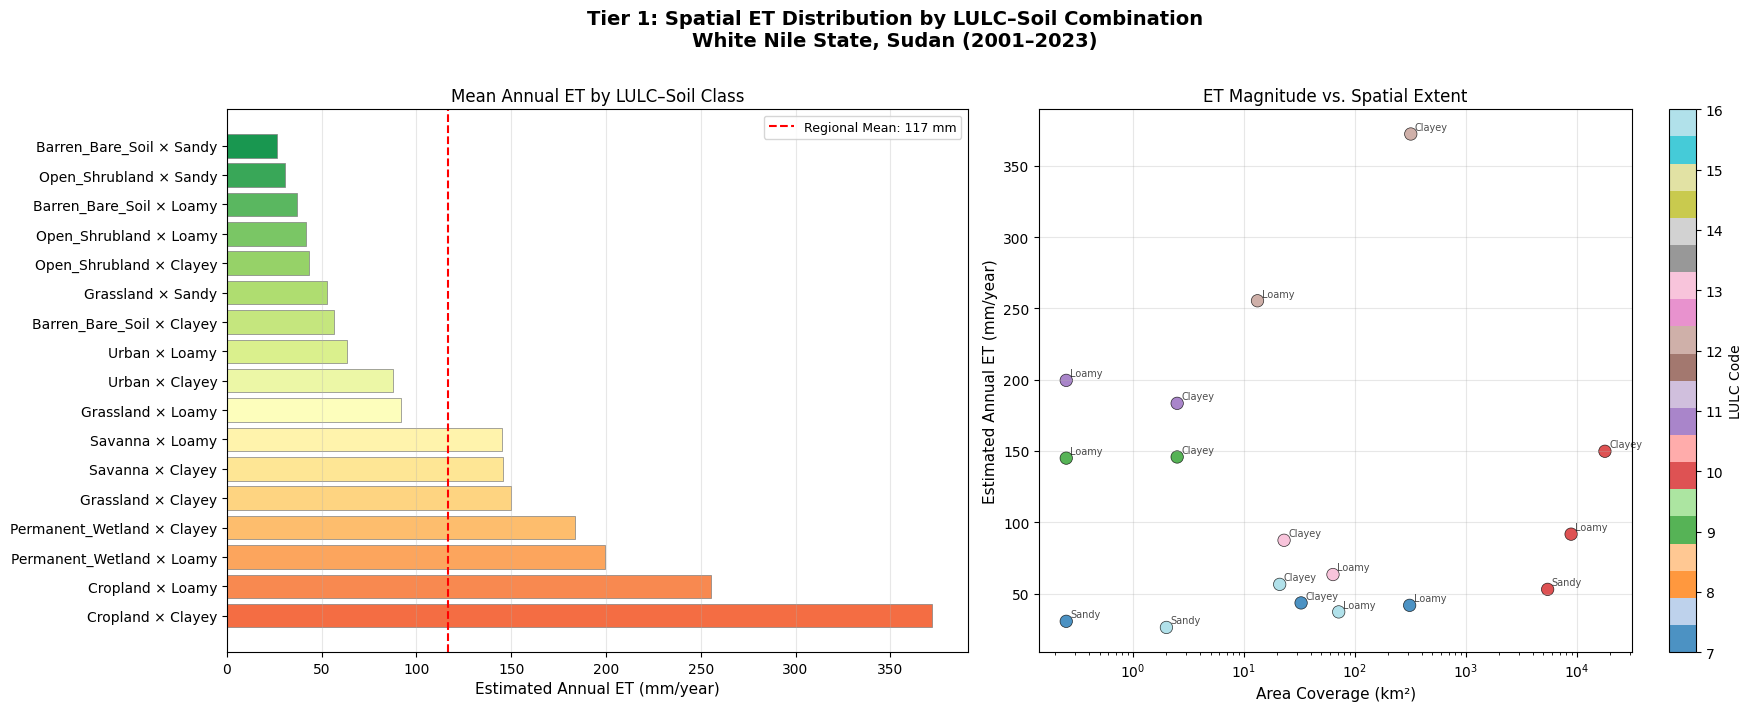

💾 Saved: F1_Spatial_ET_Bar_Scatter.png
📤 GEE Export started: ET_Annual_Mean_mm → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: EF_Mean_2001_2023 → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: LULC_Soil_Combined → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: LULC_2022_500m → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: Soil_Class_500m → Drive/ET_WhiteNile_Analysis/geotiff/

⏳ Check GEE Tasks tab (or run ee.batch.Task.list()) for export status.


In [48]:
# @title Default title text
# ║      NOTEBOOK 2 — TIER 1: SPATIAL ANALYSIS (LULC × SOIL ZONAL STATS)      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 3

# ── 2.1  Resample LULC and Soil to MOD16 resolution (500 m) ─────────────────
# MODIS native projection: Sinusoidal, 500 m
modis_proj = MOD16.first().select('ET_mm').projection()

LULC_500m = LULC.reproject(crs=modis_proj, scale=500)
SOIL_500m  = SOIL.reproject(crs=modis_proj, scale=500)

# ── 2.2  Create the Combine raster: LULC × SOIL intersection ────────────────
# Encode as: combined_class = (LULC_class * 10) + SOIL_class
# This creates a unique integer per LULC–Soil combination
COMBINED = (LULC_500m.multiply(10)
                     .add(SOIL_500m)
                     .rename('LULC_Soil_Class')
                     .reproject(crs=modis_proj, scale=500))

# ── 2.3  Compute multi-year mean ET and EF (full period) ────────────────────
ET_mean_full  = MOD16.select('ET_mm').mean().clip(aoi_geometry)
PET_mean_full = MOD16.select('PET_mm').mean().clip(aoi_geometry)
EF_mean_full  = MOD16.select('EF').mean().clip(aoi_geometry)

# Annual ET total (multiply 8-day mean by 46 composites ≈ 365 days / 8 days)
ET_annual_approx = ET_mean_full.multiply(46).rename('ET_annual_mm')

# ── 2.4  Zonal statistics: Mean ET per LULC–Soil class ──────────────────────
def compute_zonal_stats_gee(et_image, combined_img, geometry, scale=500):
    """
    Compute mean ET per LULC-Soil combination using GEE reduceRegion.
    Returns a list of dicts with class code, mean ET, pixel count.
    """
    # Stack ET + combined class into one image
    # Add et_image again so that reduceRegion has 3 bands for mean, count, and grouping
    stacked = et_image.addBands(combined_img).addBands(et_image)

    # Explicitly name the output properties for robustness
    mean_reducer = ee.Reducer.mean().setOutputs(['mean_et_output'])
    count_reducer = ee.Reducer.count().setOutputs(['count_et_output'])

    # Use grouped reducer
    stats = stacked.reduceRegion(
        reducer=mean_reducer.combine(
            reducer2=count_reducer,
            sharedInputs=False
        ).group(
            groupField=1,       # group by COMBINED band (index 1)
            groupName='class'
        ),
        geometry=geometry,
        scale=scale,
        maxPixels=1e10,
        bestEffort=True
    )
    return stats.getInfo()

raw_stats = compute_zonal_stats_gee(ET_mean_full, COMBINED, aoi_geometry)

# ── 2.5  Parse GEE output into a clean DataFrame ────────────────────────────
def parse_zonal_stats(raw_stats, et_col='mean_et_output', count_col='count_et_output'):
    rows = []
    groups = raw_stats.get('groups', [])
    for g in groups:
        code        = int(g['class'])
        lulc_val    = code // 10
        soil_val    = code % 10
        lulc_name   = LULC_CLASSES.get(lulc_val, f'Class_{lulc_val}')
        soil_name   = SOIL_CLASSES.get(soil_val, f'Soil_{soil_val}')
        mean_et     = g.get(et_col, None)
        pixel_count = g.get(count_col, 0)
        if mean_et is not None and pixel_count > 0:   # filter tiny fragments
            rows.append({
                'LULC_Code':   lulc_val,
                'Soil_Code':   soil_val,
                'LULC_Name':   lulc_name,
                'Soil_Name':   soil_name,
                'Combo_Code':  code,
                'Combo_Label': f'{lulc_name} × {soil_name}',
                'Mean_ET_8day_mm':    round(mean_et, 3),
                'Est_Annual_ET_mm':   round(mean_et * 46, 1),
                'Pixel_Count':        int(pixel_count),
                'Area_km2':           round(int(pixel_count) * 0.25, 2)  # 500m × 500m = 0.25 km²
            })
    df = pd.DataFrame(rows).sort_values('Mean_ET_8day_mm', ascending=False).reset_index(drop=True)
    df['Rank'] = df.index + 1

    # ── Post-filter: remove soil_0 artefacts ────────────────────────────────
    # Soil code 0 means masked/missing soil data (water, urban, AOI edge pixels).
    # These are not real soil classes and must be excluded from analysis.
    before = len(df)
    df = df[df['Soil_Code'] != 0].reset_index(drop=True)
    df['Rank'] = df.index + 1
    removed = before - len(df)
    if removed > 0:
        print(f"  ℹ️  Removed {removed} soil_0 artefact row(s) "
              f"(masked pixels — water bodies / urban / AOI edges)")
    return df

df_spatial = parse_zonal_stats(raw_stats)
print(f"✅ Spatial zonal stats computed: {len(df_spatial)} LULC–Soil combinations")
print(df_spatial[['Combo_Label','Mean_ET_8day_mm','Est_Annual_ET_mm','Area_km2','Rank']].to_string(index=False))

# Save to CSV
df_spatial.to_csv(f'{OUTPUT_DIR}/tables/T1_Spatial_Zonal_Stats.csv', index=False)
print(f"\n💾 Saved: T1_Spatial_Zonal_Stats.csv")

# ── 2.6  Statistical Testing: ANOVA + Kruskal-Wallis across LULC classes ────
# Sample ET values per LULC class for statistical testing
# (GEE returns grouped means; we use pixel-level sampling for testing)
print("\n--- Sampling pixel-level ET values for statistical tests ---")

sample_pts = ET_mean_full.addBands(LULC_500m).addBands(SOIL_500m).sample(
    region=aoi_geometry,
    scale=500,
    numPixels=5000,
    seed=42,
    geometries=False
)
sample_df = pd.DataFrame(sample_pts.getInfo()['features'])
sample_df = pd.DataFrame([f['properties'] for f in sample_pts.getInfo()['features']])
sample_df.columns = ['ET_mm', 'LULC', 'Soil']
sample_df = sample_df.dropna()
sample_df['LULC_Name'] = sample_df['LULC'].map(LULC_CLASSES)
sample_df['Soil_Name'] = sample_df['Soil'].map(SOIL_CLASSES)

# Kruskal-Wallis test (non-parametric — appropriate for ET distributions)
groups_by_lulc = [g['ET_mm'].values for _, g in sample_df.groupby('LULC_Name') if len(g) > 5]
if len(groups_by_lulc) >= 2:
    kw_stat, kw_p = kruskal(*groups_by_lulc)
    print(f"\n🔬 Kruskal-Wallis Test (ET across LULC classes):")
    print(f"   H-statistic = {kw_stat:.3f} | p-value = {kw_p:.6f}")
    if kw_p < 0.05:
        print("   ✅ Significant difference in ET across LULC classes (p < 0.05)")
    else:
        print("   ⚠️ No significant difference detected (p ≥ 0.05)")

# Tukey HSD post-hoc
tukey_data   = sample_df.dropna(subset=['ET_mm','LULC_Name'])
tukey_result = pairwise_tukeyhsd(tukey_data['ET_mm'], tukey_data['LULC_Name'], alpha=0.05)
tukey_df     = pd.DataFrame(data=tukey_result._results_table.data[1:],
                             columns=tukey_result._results_table.data[0])
tukey_df.to_csv(f'{OUTPUT_DIR}/tables/T2_Tukey_HSD_PostHoc.csv', index=False)
print(f"\n💾 Saved: T2_Tukey_HSD_PostHoc.csv")
print(tukey_df.to_string(index=False))

# ── 2.7  FIGURE 1: Bar chart — Mean Annual ET by LULC–Soil combination ──────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Tier 1: Spatial ET Distribution by LULC–Soil Combination\nWhite Nile State, Sudan (2001–2023)',
             fontsize=14, fontweight='bold', y=1.01)

# Left panel: horizontal bar chart of annual ET
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_spatial)))
ax = axes[0]
bars = ax.barh(df_spatial['Combo_Label'], df_spatial['Est_Annual_ET_mm'],
               color=colors_bar, edgecolor='grey', linewidth=0.5)
ax.set_xlabel('Estimated Annual ET (mm/year)', fontsize=11)
ax.set_title('Mean Annual ET by LULC–Soil Class', fontsize=12)
ax.axvline(df_spatial['Est_Annual_ET_mm'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Regional Mean: {df_spatial["Est_Annual_ET_mm"].mean():.0f} mm')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Right panel: scatter — Area coverage vs. ET magnitude
ax2 = axes[1]
scatter = ax2.scatter(df_spatial['Area_km2'],
                      df_spatial['Est_Annual_ET_mm'],
                      s=80, c=df_spatial['LULC_Code'],
                      cmap='tab20', alpha=0.8, edgecolors='k', linewidths=0.5)
for _, row in df_spatial.iterrows():
    ax2.annotate(row['Soil_Name'], (row['Area_km2'], row['Est_Annual_ET_mm']),
                 fontsize=7, alpha=0.7, xytext=(3,3), textcoords='offset points')
ax2.set_xlabel('Area Coverage (km²)', fontsize=11)
ax2.set_ylabel('Estimated Annual ET (mm/year)', fontsize=11)
ax2.set_title('ET Magnitude vs. Spatial Extent', fontsize=12)
ax2.set_xscale('log')
ax2.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='LULC Code')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/F1_Spatial_ET_Bar_Scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: F1_Spatial_ET_Bar_Scatter.png")

# ── 2.8  Export GeoTIFF maps ─────────────────────────────────────────────────
def export_geotiff(image, description, folder, scale=500, region=None):
    """Export a GEE image to Google Drive as GeoTIFF."""
    if region is None:
        region = aoi_geometry
    task = ee.batch.Export.image.toDrive(
        image=image.clip(region),
        description=description,
        folder=folder,
        fileNamePrefix=description,
        region=region,
        scale=scale,
        crs='EPSG:4326',
        maxPixels=1e13,
        fileFormat='GeoTIFF'
    )
    task.start()
    print(f"📤 GEE Export started: {description} → Drive/{folder}/")
    return task

task1 = export_geotiff(ET_annual_approx,   'ET_Annual_Mean_mm',  'ET_WhiteNile_Analysis/geotiff')
task2 = export_geotiff(EF_mean_full,        'EF_Mean_2001_2023',  'ET_WhiteNile_Analysis/geotiff')
task3 = export_geotiff(COMBINED,            'LULC_Soil_Combined', 'ET_WhiteNile_Analysis/geotiff')
task4 = export_geotiff(LULC_500m,           'LULC_2022_500m',     'ET_WhiteNile_Analysis/geotiff')
task5 = export_geotiff(SOIL_500m,           'Soil_Class_500m',    'ET_WhiteNile_Analysis/geotiff')
print("\n⏳ Check GEE Tasks tab (or run ee.batch.Task.list()) for export status.")

✅ Seasonal zonal stats computed
💾 Saved: T3_Seasonal_Zonal_Stats.csv

--- Building annual ET time series (2001–2023) ---
✅ Annual time series built: 184 records
💾 Saved: T4_Annual_ET_TimeSeries.csv

--- Mann-Kendall Trend Analysis ---
  Barren_Bare_Soil                    | Trend: increasing  | p=0.0089 | Sen's slope: 2.02 mm/yr | Sig: ✅
  Cropland                            | Trend: increasing  | p=0.0419 | Sen's slope: 2.56 mm/yr | Sig: ✅
  Grassland                           | Trend: increasing  | p=0.0083 | Sen's slope: 3.36 mm/yr | Sig: ✅
  Open_Shrubland                      | Trend: increasing  | p=0.0096 | Sen's slope: 1.55 mm/yr | Sig: ✅
  Permanent_Wetland                   | Trend: increasing  | p=0.0026 | Sen's slope: 4.46 mm/yr | Sig: ✅
  Savanna                             | Trend: increasing  | p=0.0011 | Sen's slope: 3.97 mm/yr | Sig: ✅
  Urban                               | Trend: increasing  | p=0.0130 | Sen's slope: 2.53 mm/yr | Sig: ✅
  Water                       

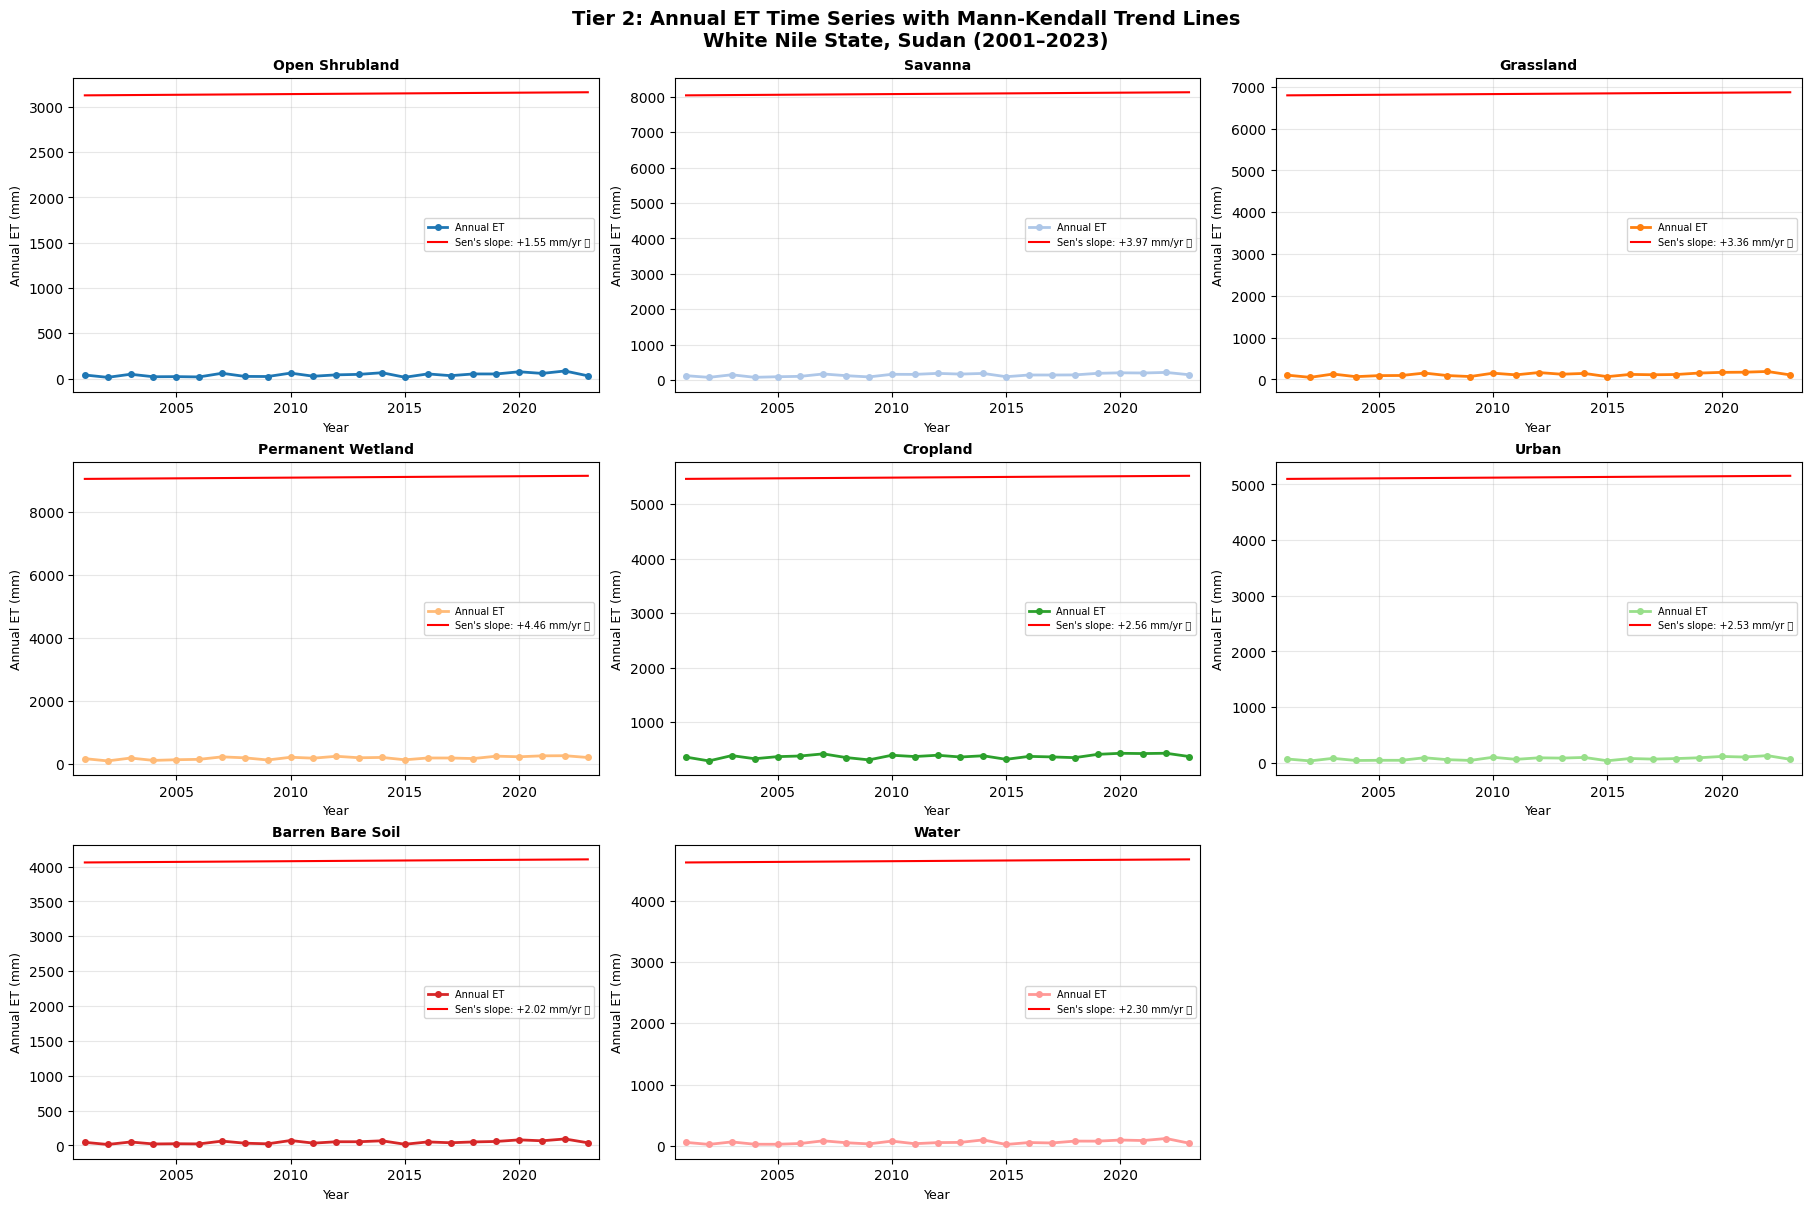

💾 Saved: F2_TimeSeries_MannKendall.png


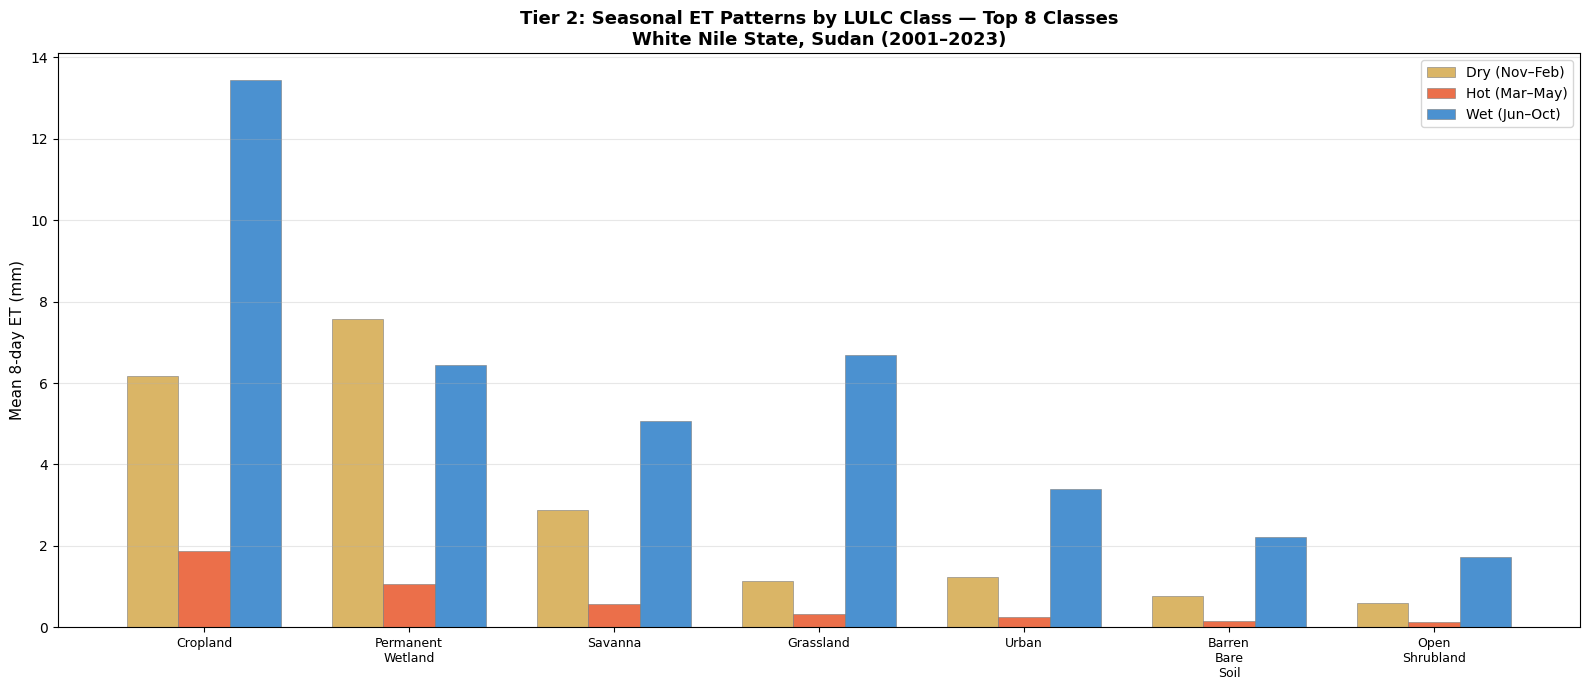

💾 Saved: F3_Seasonal_ET_Grouped_Bar.png
📤 GEE Export started: ET_Seasonal_Dry_Nov_Feb → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: ET_Seasonal_Hot_Mar_May → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: ET_Seasonal_Wet_Jun_Oct → Drive/ET_WhiteNile_Analysis/geotiff/


In [51]:
import ee
import geemap
import geemap.colormaps as cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pymannkendall as mk
import os
import warnings
warnings.filterwarnings('ignore')

# @title Default title text
# ║    NOTEBOOK 3 — TIER 2: TEMPORAL ANALYSIS (SEASONAL + TREND DETECTION)     ║
# ═══════════════════════════════════════════════════════════════════════════════
# Paste this block into Cell 4

# ── 3.1  Seasonal ET computation ─═════════════════════════════════════════
def get_seasonal_et(collection, months, start_yr, end_yr, geometry):
    """Compute mean ET for a list of months across all years."""
    months_ee = ee.List(months)
    filtered = collection.filter(
        ee.Filter.calendarRange(months[0], months[-1], 'month')
    )
    return filtered.select('ET_mm').mean().clip(geometry)

ET_dry = get_seasonal_et(MOD16, SEASONS['Dry'], START_YEAR, END_YEAR, aoi_geometry)
ET_hot = get_seasonal_et(MOD16, SEASONS['Hot'], START_YEAR, END_YEAR, aoi_geometry)
ET_wet = get_seasonal_et(MOD16, SEASONS['Wet'], START_YEAR, END_YEAR, aoi_geometry)

# Zonal stats per season per LULC–Soil class
def seasonal_zonal(et_img, label):
    raw = compute_zonal_stats_gee(et_img, COMBINED, aoi_geometry)
    df  = parse_zonal_stats(raw)
    df['Season'] = label
    return df

df_dry = seasonal_zonal(ET_dry, 'Dry (Nov–Feb)')
df_hot = seasonal_zonal(ET_hot, 'Hot (Mar–May)')
df_wet = seasonal_zonal(ET_wet, 'Wet (Jun–Oct)')

df_seasonal = pd.concat([df_dry, df_hot, df_wet], ignore_index=True)
df_seasonal.to_csv(f'{OUTPUT_DIR}/tables/T3_Seasonal_Zonal_Stats.csv', index=False)
print("✅ Seasonal zonal stats computed")
print("💾 Saved: T3_Seasonal_Zonal_Stats.csv")

# ── 3.2  Annual ET time series per LULC class ─═══════════════════════════════════════
print("\n--- Building annual ET time series (2001–2023) ---")

def get_annual_et_by_lulc(year):
    """Compute mean ET per LULC class for a given year."""
    yr_col = (MOD16.filter(ee.Filter.calendarRange(year, year, 'year'))
                   .select('ET_mm')
                   .mean()
                   .clip(aoi_geometry))

    stats = yr_col.addBands(LULC_500m).reduceRegion(
        reducer=ee.Reducer.mean().group(groupField=1, groupName='lulc'),
        geometry=aoi_geometry,
        scale=500,
        maxPixels=1e10,
        bestEffort=True
    )
    return ee.Feature(None, stats.set('year', year))

years       = list(range(START_YEAR, END_YEAR + 1))
annual_fc   = ee.FeatureCollection([get_annual_et_by_lulc(y) for y in years])
annual_info = annual_fc.getInfo()['features']

# Parse into long-format DataFrame
rows_ts = []
for feat in annual_info:
    yr     = feat['properties']['year']
    groups = feat['properties'].get('groups', [])
    for g in groups:
        lulc_val = int(g['lulc'])
        et_val   = g.get('mean', None) # Changed 'ET_mm_mean' to 'mean'
        if et_val is not None and lulc_val in LULC_CLASSES:
            rows_ts.append({
                'Year':      yr,
                'LULC_Code': lulc_val,
                'LULC_Name': LULC_CLASSES[lulc_val],
                'Mean_ET_8day_mm': round(et_val, 3),
                'Est_Annual_ET_mm': round(et_val * 46, 1)
            })

df_timeseries = pd.DataFrame(rows_ts)
df_timeseries.to_csv(f'{OUTPUT_DIR}/tables/T4_Annual_ET_TimeSeries.csv', index=False)
print(f"✅ Annual time series built: {len(df_timeseries)} records")
print("💾 Saved: T4_Annual_ET_TimeSeries.csv")

# ── 3.3  Mann-Kendall Trend Test per LULC class ─══════════════════════════════════
print("\n--- Mann-Kendall Trend Analysis ---")
trend_results = []

for lulc_name, grp in df_timeseries.groupby('LULC_Name'):
    grp_sorted = grp.sort_values('Year')
    if len(grp_sorted) < 5:
        continue
    series = grp_sorted['Est_Annual_ET_mm'].values
    result = mk.original_test(series)

    trend_results.append({
        'LULC_Name':        lulc_name,
        'MK_Trend':         result.trend,
        'MK_p_value':       round(result.p, 4),
        'MK_Tau':           round(result.Tau, 3),
        'Sens_Slope_mm_yr': round(result.slope, 3),
        'Sens_Intercept':   round(result.intercept, 2),
        'Significant':      'Yes' if result.p < 0.05 else 'No',
        'n_years':          len(grp_sorted)
    })
    print(f"  {lulc_name:35s} | Trend: {result.trend:11s} | p={result.p:.4f} | "
          f"Sen's slope: {result.slope:.2f} mm/yr | Sig: {'✅' if result.p < 0.05 else '—'}")

df_trends = pd.DataFrame(trend_results)
df_trends.to_csv(f'{OUTPUT_DIR}/tables/T5_MannKendall_Trends.csv', index=False)
print(f"\n══ Saved: T5_MannKendall_Trends.csv")

# ── 3.4  FIGURE 2: Time series with trend lines ─═════════════════════════════
lulc_names_present = df_timeseries['LULC_Name'].unique()
n_classes = len(lulc_names_present)
cols_ts = 3
rows_ts_plot = (n_classes + cols_ts - 1) // cols_ts

fig, axes = plt.subplots(rows_ts_plot, cols_ts,
                         figsize=(18, rows_ts_plot * 4),
                         constrained_layout=True)
axes_flat = axes.flatten()

palette = sns.color_palette('tab20', n_classes)

for i, lulc_name in enumerate(lulc_names_present):
    ax    = axes_flat[i]
    grp   = df_timeseries[df_timeseries['LULC_Name'] == lulc_name].sort_values('Year')
    trend = df_trends[df_trends['LULC_Name'] == lulc_name]

    ax.plot(grp['Year'], grp['Est_Annual_ET_mm'],
            color=palette[i], linewidth=2, marker='o', markersize=4, label='Annual ET')

    if not trend.empty:
        slope   = trend['Sens_Slope_mm_yr'].values[0]
        intcept = trend['Sens_Intercept'].values[0]
        trend_y = [slope * yr + intcept for yr in grp['Year']]
        sig     = trend['Significant'].values[0]
        style   = '-' if sig == 'Yes' else '--'
        lbl     = f"Sen's slope: {slope:+.2f} mm/yr {'✅' if sig=='Yes' else ''}"
        ax.plot(grp['Year'], trend_y, color='red', linewidth=1.5,
                linestyle=style, label=lbl)

    ax.set_title(lulc_name.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Annual ET (mm)', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)

# Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Tier 2: Annual ET Time Series with Mann-Kendall Trend Lines\n'
             'White Nile State, Sudan (2001–2023)', fontsize=14, fontweight='bold')
plt.savefig(f'{OUTPUT_DIR}/plots/F2_TimeSeries_MannKendall.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: F2_TimeSeries_MannKendall.png")

# ── 3.5  FIGURE 3: Seasonal box plots ─═════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 7))

# Pivot for grouped plotting
top_classes = (df_spatial.groupby('LULC_Name')['Est_Annual_ET_mm']
                          .mean()
                          .nlargest(8)
                          .index.tolist())
df_seas_top = df_seasonal[df_seasonal['LULC_Name'].isin(top_classes)]

season_order  = ['Dry (Nov–Feb)', 'Hot (Mar–May)', 'Wet (Jun–Oct)']
season_colors = {'Dry (Nov–Feb)': '#d4a84b',    # sandy amber
                 'Hot (Mar–May)': '#e8562a',     # burnt orange
                 'Wet (Jun–Oct)': '#2b7ec8'}     # deep blue

x = np.arange(len(top_classes))
width = 0.25
for j, season in enumerate(season_order):
    seas_data = df_seas_top[df_seas_top['Season'] == season]
    et_vals = [seas_data[seas_data['LULC_Name'] == cls]['Mean_ET_8day_mm'].values
               for cls in top_classes]
    et_means = [v[0] if len(v) > 0 else 0 for v in et_vals]
    ax.bar(x + j * width, et_means, width, label=season,
           color=season_colors[season], alpha=0.85, edgecolor='grey', linewidth=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace('_', '\n') for c in top_classes], fontsize=9)
ax.set_ylabel('Mean 8-day ET (mm)', fontsize=11)
ax.set_title('Tier 2: Seasonal ET Patterns by LULC Class — Top 8 Classes\n'
             'White Nile State, Sudan (2001–2023)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/F3_Seasonal_ET_Grouped_Bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: F3_Seasonal_ET_Grouped_Bar.png")

# Export seasonal ET maps
task6 = export_geotiff(ET_dry, 'ET_Seasonal_Dry_Nov_Feb',  'ET_WhiteNile_Analysis/geotiff')
task7 = export_geotiff(ET_hot, 'ET_Seasonal_Hot_Mar_May',  'ET_WhiteNile_Analysis/geotiff')
task8 = export_geotiff(ET_wet, 'ET_Seasonal_Wet_Jun_Oct',  'ET_WhiteNile_Analysis/geotiff')


Processing 17 LULC-Soil classes...
  [01/17] Code  123 (Cropland x Clayey): ET=372.2 mm, P=390.4 mm, Surplus=18.2 mm
  [02/17] Code  122 (Cropland x Loamy): ET=255.3 mm, P=328.5 mm, Surplus=73.1 mm
  [04/17] Code  113 (Permanent_Wetland x Clayey): ET=183.4 mm, P=378.2 mm, Surplus=179.2 mm
  [05/17] Code  103 (Grassland x Clayey): ET=149.8 mm, P=387.7 mm, Surplus=238.2 mm
  [06/17] Code   93 (Savanna x Clayey): ET=145.8 mm, P=293.3 mm, Surplus=147.5 mm
  [08/17] Code  102 (Grassland x Loamy): ET=91.7 mm, P=326.2 mm, Surplus=238.5 mm
  [09/17] Code  133 (Urban x Clayey): ET=87.4 mm, P=288.9 mm, Surplus=197.2 mm
  [10/17] Code  132 (Urban x Loamy): ET=63.4 mm, P=237.8 mm, Surplus=158.0 mm
  [11/17] Code  163 (Barren_Bare_Soil x Clayey): ET=56.5 mm, P=243.6 mm, Surplus=171.5 mm
  [12/17] Code  101 (Grassland x Sandy): ET=53.0 mm, P=279.3 mm, Surplus=242.6 mm
  [13/17] Code   73 (Open_Shrubland x Clayey): ET=43.5 mm, P=188.0 mm, Surplus=144.1 mm
  [14/17] Code   72 (Open_Shrubland x Loamy):

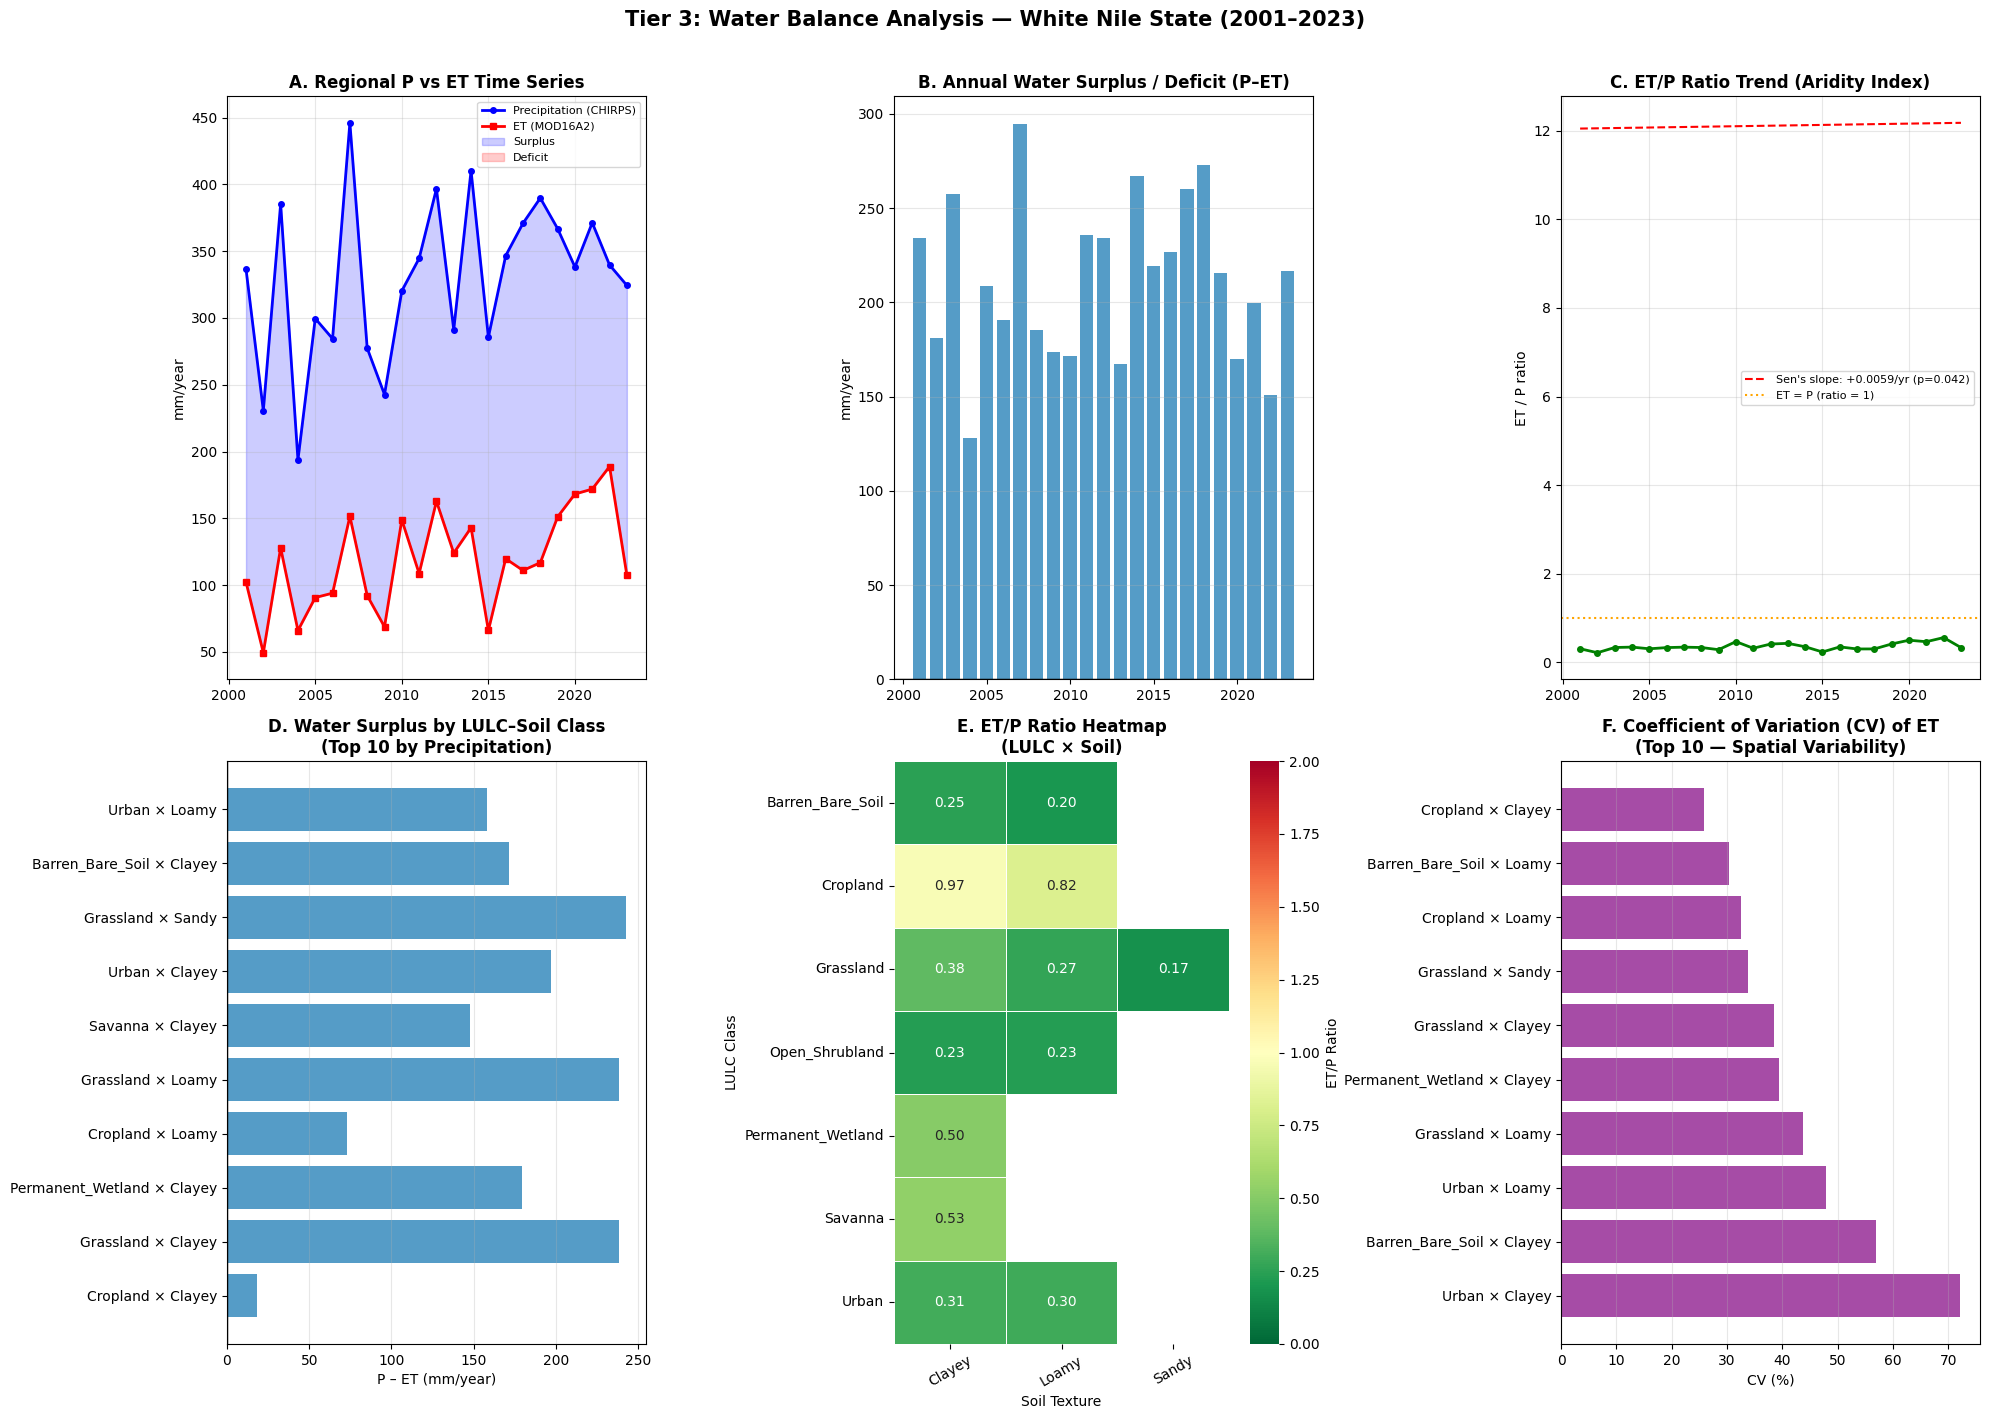

💾 Saved: F4_WaterBalance_Dashboard.png
📤 GEE Export started: WaterBalance_Surplus_mm → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: WaterBalance_Deficit_mm → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: Aridity_Index_ET_over_P → Drive/ET_WhiteNile_Analysis/geotiff/
📤 GEE Export started: Precip_Annual_Mean_CHIRPS_mm → Drive/ET_WhiteNile_Analysis/geotiff/


In [52]:
# @title Default title text
# ║       NOTEBOOK 4 — TIER 3: HYDROLOGICAL INTEGRATION (WATER BALANCE)       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 5

# ── 4.1  Annual Precipitation from CHIRPS ────────────────────────────────────
def get_annual_precip(year):
    """Sum daily CHIRPS precipitation to annual total."""
    return (CHIRPS.filter(ee.Filter.calendarRange(year, year, 'year'))
                  .sum()
                  .clip(aoi_geometry)
                  .rename('Precip_mm'))

# Multi-year mean precipitation
precip_annual_mean = (ee.ImageCollection(
    [get_annual_precip(y) for y in years]
).mean().clip(aoi_geometry))

# ── 4.2  Water Balance Components ────────────────────────────────────────────
# P - ET = Surplus (positive) or Deficit (negative)
# Surplus: water potentially available for runoff / recharge
# Deficit: water stress / unmet evaporative demand

water_surplus  = precip_annual_mean.subtract(ET_annual_approx).rename('Water_Surplus_mm')
water_deficit  = PET_mean_full.multiply(46).subtract(ET_annual_approx).rename('Water_Deficit_mm')
aridity_index  = ET_annual_approx.divide(precip_annual_mean).rename('Aridity_Index_ET_P')

# ── 4.3  Zonal water balance per LULC–Soil class ─────────────────────────────
# GEE HARD CONSTRAINT: ee.Reducer.group() requires that the grouping band is
# the LAST band in the image AND that no combined reducers are used together
# with group(). The safest, most reliable approach is to avoid grouped reducers
# entirely and instead iterate over each unique LULC-Soil class in Python,
# masking the image to that class and calling reduceRegion independently.
# This avoids ALL GEE reducer chaining / ordering errors completely.

# -- Water balance image stack (no group band embedded) -----------------------
wb_stack = (ET_annual_approx
              .addBands(precip_annual_mean.rename('Precip_mm'))
              .addBands(water_surplus)
              .addBands(water_deficit)
              .addBands(aridity_index))

# -- Get unique LULC-Soil class codes present in the AOI ---------------------
# Use the df_spatial table already computed in Notebook 2 (Tier 1)
# which contains all valid combo codes with pixel_count > 10.
unique_codes = df_spatial['Combo_Code'].tolist()
print(f"Processing {len(unique_codes)} LULC-Soil classes...")

wb_rows = []
for i, code in enumerate(unique_codes):
    lulc_val = code // 10
    soil_val = code % 10

    # Mask the water balance stack to pixels belonging to this class only
    class_mask = COMBINED.eq(int(code))
    wb_masked  = wb_stack.updateMask(class_mask)

    # reduceRegion with mean + stdDev as SEPARATE calls (no grouping needed)
    try:
        mean_vals = wb_masked.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi_geometry,
            scale=500,
            maxPixels=1e10,
            bestEffort=True
        ).getInfo()

        std_vals = wb_masked.reduceRegion(
            reducer=ee.Reducer.stdDev(),
            geometry=aoi_geometry,
            scale=500,
            maxPixels=1e10,
            bestEffort=True
        ).getInfo()

        cnt_vals = wb_masked.select('ET_annual_mm').reduceRegion(
            reducer=ee.Reducer.count(),
            geometry=aoi_geometry,
            scale=500,
            maxPixels=1e10,
            bestEffort=True
        ).getInfo()

        pixel_n = cnt_vals.get('ET_annual_mm', 0) or 0
        if pixel_n < 10:
            continue

        et_mean    = mean_vals.get('ET_annual_mm',      0) or 0
        sd_et      = std_vals.get('ET_annual_mm',       0) or 0
        p_mean     = mean_vals.get('Precip_mm',         0) or 0
        sd_p       = std_vals.get('Precip_mm',          0) or 0
        surp_mean  = mean_vals.get('Water_Surplus_mm',  0) or 0
        defic_mean = mean_vals.get('Water_Deficit_mm',  0) or 0
        ai_mean    = mean_vals.get('Aridity_Index_ET_P',0) or 0

        wb_rows.append({
            'LULC_Name':        LULC_CLASSES.get(lulc_val, f'Class_{lulc_val}'),
            'Soil_Name':        SOIL_CLASSES.get(soil_val, f'Soil_{soil_val}'),
            'Combo_Code':       code,
            'Pixel_Count':      int(pixel_n),
            'Area_km2':         round(int(pixel_n) * 0.25, 1),
            'Mean_ET_mm':       round(et_mean,    1),
            'Mean_Precip_mm':   round(p_mean,     1),
            'Water_Surplus_mm': round(surp_mean,  1),
            'Water_Deficit_mm': round(defic_mean, 1),
            'ET_Precip_Ratio':  round(ai_mean,    3),
            'SD_ET_mm':         round(sd_et,      1),
            'SD_Precip_mm':     round(sd_p,       1),
        })
        print(f"  [{i+1:02d}/{len(unique_codes)}] Code {code:4d} "
              f"({LULC_CLASSES.get(lulc_val,'?')} x {SOIL_CLASSES.get(soil_val,'?')}): "
              f"ET={et_mean:.1f} mm, P={p_mean:.1f} mm, "
              f"Surplus={surp_mean:.1f} mm")

    except Exception as ex:
        print(f"  ⚠️  Code {code} skipped: {ex}")
        continue

df_waterbalance = (pd.DataFrame(wb_rows)
                     .sort_values('Water_Surplus_mm', ascending=False)
                     .reset_index(drop=True))

# CV = SD / Mean × 100
df_waterbalance['CV_ET_pct'] = round(
    df_waterbalance['SD_ET_mm'] / df_waterbalance['Mean_ET_mm'].replace(0, np.nan) * 100, 1)

df_waterbalance.to_csv(f'{OUTPUT_DIR}/tables/T6_WaterBalance_by_Class.csv', index=False)
print("✅ Water balance table computed")
print("💾 Saved: T6_WaterBalance_by_Class.csv")
print(df_waterbalance.to_string(index=False))

# ── 4.4  Annual P and ET time series for trend comparison ────────────────────
precip_ts_rows = []
for year in years:
    precip_yr = (CHIRPS.filter(ee.Filter.calendarRange(year, year, 'year'))
                        .sum()
                        .reduceRegion(
                            reducer=ee.Reducer.mean(),
                            geometry=aoi_geometry,
                            scale=5000,
                            maxPixels=1e10,
                            bestEffort=True
                        ).getInfo())
    et_yr = (MOD16.filter(ee.Filter.calendarRange(year, year, 'year'))
                   .select('ET_mm')
                   .mean()
                   .multiply(46)
                   .reduceRegion(
                       reducer=ee.Reducer.mean(),
                       geometry=aoi_geometry,
                       scale=500,
                       maxPixels=1e10,
                       bestEffort=True
                   ).getInfo())
    precip_ts_rows.append({
        'Year':       year,
        'Precip_mm':  round(precip_yr.get('precipitation', 0), 1),
        'ET_mm':      round(et_yr.get('ET_mm', 0) if et_yr.get('ET_mm') else 0, 1)
    })

df_wb_ts = pd.DataFrame(precip_ts_rows)
df_wb_ts['P_minus_ET'] = df_wb_ts['Precip_mm'] - df_wb_ts['ET_mm']
df_wb_ts['ET_P_ratio']  = (df_wb_ts['ET_mm'] / df_wb_ts['Precip_mm'].replace(0, np.nan)).round(3)
df_wb_ts.to_csv(f'{OUTPUT_DIR}/tables/T7_Annual_WaterBalance_TimeSeries.csv', index=False)
print("💾 Saved: T7_Annual_WaterBalance_TimeSeries.csv")

# ── 4.5  FIGURE 4: Water Balance Dashboard ──────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Tier 3: Water Balance Analysis — White Nile State (2001–2023)',
             fontsize=15, fontweight='bold', y=1.01)

# Panel A: ET vs P time series
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(df_wb_ts['Year'], df_wb_ts['Precip_mm'], 'b-o', markersize=4,
         linewidth=2, label='Precipitation (CHIRPS)')
ax1.plot(df_wb_ts['Year'], df_wb_ts['ET_mm'], 'r-s', markersize=4,
         linewidth=2, label='ET (MOD16A2)')
ax1.fill_between(df_wb_ts['Year'], df_wb_ts['ET_mm'], df_wb_ts['Precip_mm'],
                 where=df_wb_ts['Precip_mm'] > df_wb_ts['ET_mm'],
                 alpha=0.2, color='blue', label='Surplus')
ax1.fill_between(df_wb_ts['Year'], df_wb_ts['ET_mm'], df_wb_ts['Precip_mm'],
                 where=df_wb_ts['Precip_mm'] <= df_wb_ts['ET_mm'],
                 alpha=0.2, color='red', label='Deficit')
ax1.set_title('A. Regional P vs ET Time Series', fontweight='bold')
ax1.set_ylabel('mm/year')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Panel B: P–ET balance (surplus/deficit)
ax2 = fig.add_subplot(2, 3, 2)
colors_bal = ['#2b83ba' if v >= 0 else '#d7191c' for v in df_wb_ts['P_minus_ET']]
ax2.bar(df_wb_ts['Year'], df_wb_ts['P_minus_ET'], color=colors_bal, alpha=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('B. Annual Water Surplus / Deficit (P–ET)', fontweight='bold')
ax2.set_ylabel('mm/year')
ax2.grid(axis='y', alpha=0.3)

# Panel C: ET/P ratio trend
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(df_wb_ts['Year'], df_wb_ts['ET_P_ratio'], 'g-o', markersize=4, linewidth=2)
mk_ratio = mk.original_test(df_wb_ts['ET_P_ratio'].dropna().values)
trend_y  = [mk_ratio.slope * yr + mk_ratio.intercept for yr in df_wb_ts['Year']]
ax3.plot(df_wb_ts['Year'], trend_y, 'r--', linewidth=1.5,
         label=f"Sen's slope: {mk_ratio.slope:+.4f}/yr (p={mk_ratio.p:.3f})")
ax3.axhline(1.0, color='orange', linestyle=':', linewidth=1.5, label='ET = P (ratio = 1)')
ax3.set_title('C. ET/P Ratio Trend (Aridity Index)', fontweight='bold')
ax3.set_ylabel('ET / P ratio')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# Panel D: Water surplus by LULC-Soil class (top 10)
ax4 = fig.add_subplot(2, 3, 4)
df_wb_top = df_waterbalance.nlargest(10, 'Mean_Precip_mm')
bar_colors = ['#2b83ba' if v >= 0 else '#d7191c' for v in df_wb_top['Water_Surplus_mm']]
ax4.barh(df_wb_top['LULC_Name'] + ' × ' + df_wb_top['Soil_Name'],
         df_wb_top['Water_Surplus_mm'], color=bar_colors, alpha=0.8)
ax4.axvline(0, color='black', linewidth=1)
ax4.set_title('D. Water Surplus by LULC–Soil Class\n(Top 10 by Precipitation)', fontweight='bold')
ax4.set_xlabel('P – ET (mm/year)')
ax4.grid(axis='x', alpha=0.3)

# Panel E: ET/P ratio heatmap by class
ax5 = fig.add_subplot(2, 3, 5)
pivot_data = (df_waterbalance.pivot_table(
    values='ET_Precip_Ratio', index='LULC_Name', columns='Soil_Name', aggfunc='mean'))
sns.heatmap(pivot_data, ax=ax5, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=2, linewidths=0.5, cbar_kws={'label': 'ET/P Ratio'})
ax5.set_title('E. ET/P Ratio Heatmap\n(LULC × Soil)', fontweight='bold')
ax5.set_xlabel('Soil Texture')
ax5.set_ylabel('LULC Class')
ax5.tick_params(axis='x', rotation=30)
ax5.tick_params(axis='y', rotation=0)

# Panel F: CV of ET (uncertainty / variability)
ax6 = fig.add_subplot(2, 3, 6)
df_cv = df_waterbalance.dropna(subset=['CV_ET_pct']).nlargest(10, 'CV_ET_pct')
ax6.barh(df_cv['LULC_Name'] + ' × ' + df_cv['Soil_Name'],
         df_cv['CV_ET_pct'], color='purple', alpha=0.7)
ax6.set_title('F. Coefficient of Variation (CV) of ET\n(Top 10 — Spatial Variability)', fontweight='bold')
ax6.set_xlabel('CV (%)')
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/F4_WaterBalance_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: F4_WaterBalance_Dashboard.png")

# Export water balance rasters
task9  = export_geotiff(water_surplus,         'WaterBalance_Surplus_mm',       'ET_WhiteNile_Analysis/geotiff')
task10 = export_geotiff(water_deficit,         'WaterBalance_Deficit_mm',       'ET_WhiteNile_Analysis/geotiff')
task11 = export_geotiff(aridity_index,         'Aridity_Index_ET_over_P',       'ET_WhiteNile_Analysis/geotiff')
task12 = export_geotiff(precip_annual_mean,    'Precip_Annual_Mean_CHIRPS_mm',  'ET_WhiteNile_Analysis/geotiff')

✅ GEE initialized
✅ Output directory: /content/drive/MyDrive/ET_WhiteNile_Analysis

🔍 Loading Area of Interest...
✅ aoi_geometry: loaded from GEE asset
   Source: GEE asset: projects/ee-abdoyanes2016/assets/White_NILe_State
   Bounds: [[[31.529478652806027, 11.945129041795237], [33.25366141586904, 11.945129041795237], [33.25366141586904, 15.229493356969316], [31.529478652806027, 15.229493356969316], [31.529478652806027, 11.945129041795237]]]

🔍 Loading MOD16A2 ET data...
✅ MOD16 images: 1058

🔍 Loading/computing water balance time series...
✅ Loaded T7 from CSV: 23 rows
   Year  ET_mm  Precip_mm  P_minus_ET  ET_P_ratio
0  2001  101.4      336.6       235.2       0.301
1  2002   49.1      230.7       181.6       0.213
2  2003  126.6      385.4       258.8       0.328
3  2004   65.5      193.8       128.3       0.338
4  2005   89.8      299.6       209.8       0.300

🔬 Running NDVI-ET consistency check...
  Computing NDVI for 2001...
    NDVI = 0.2098
  Computing NDVI for 2002...
    NDV

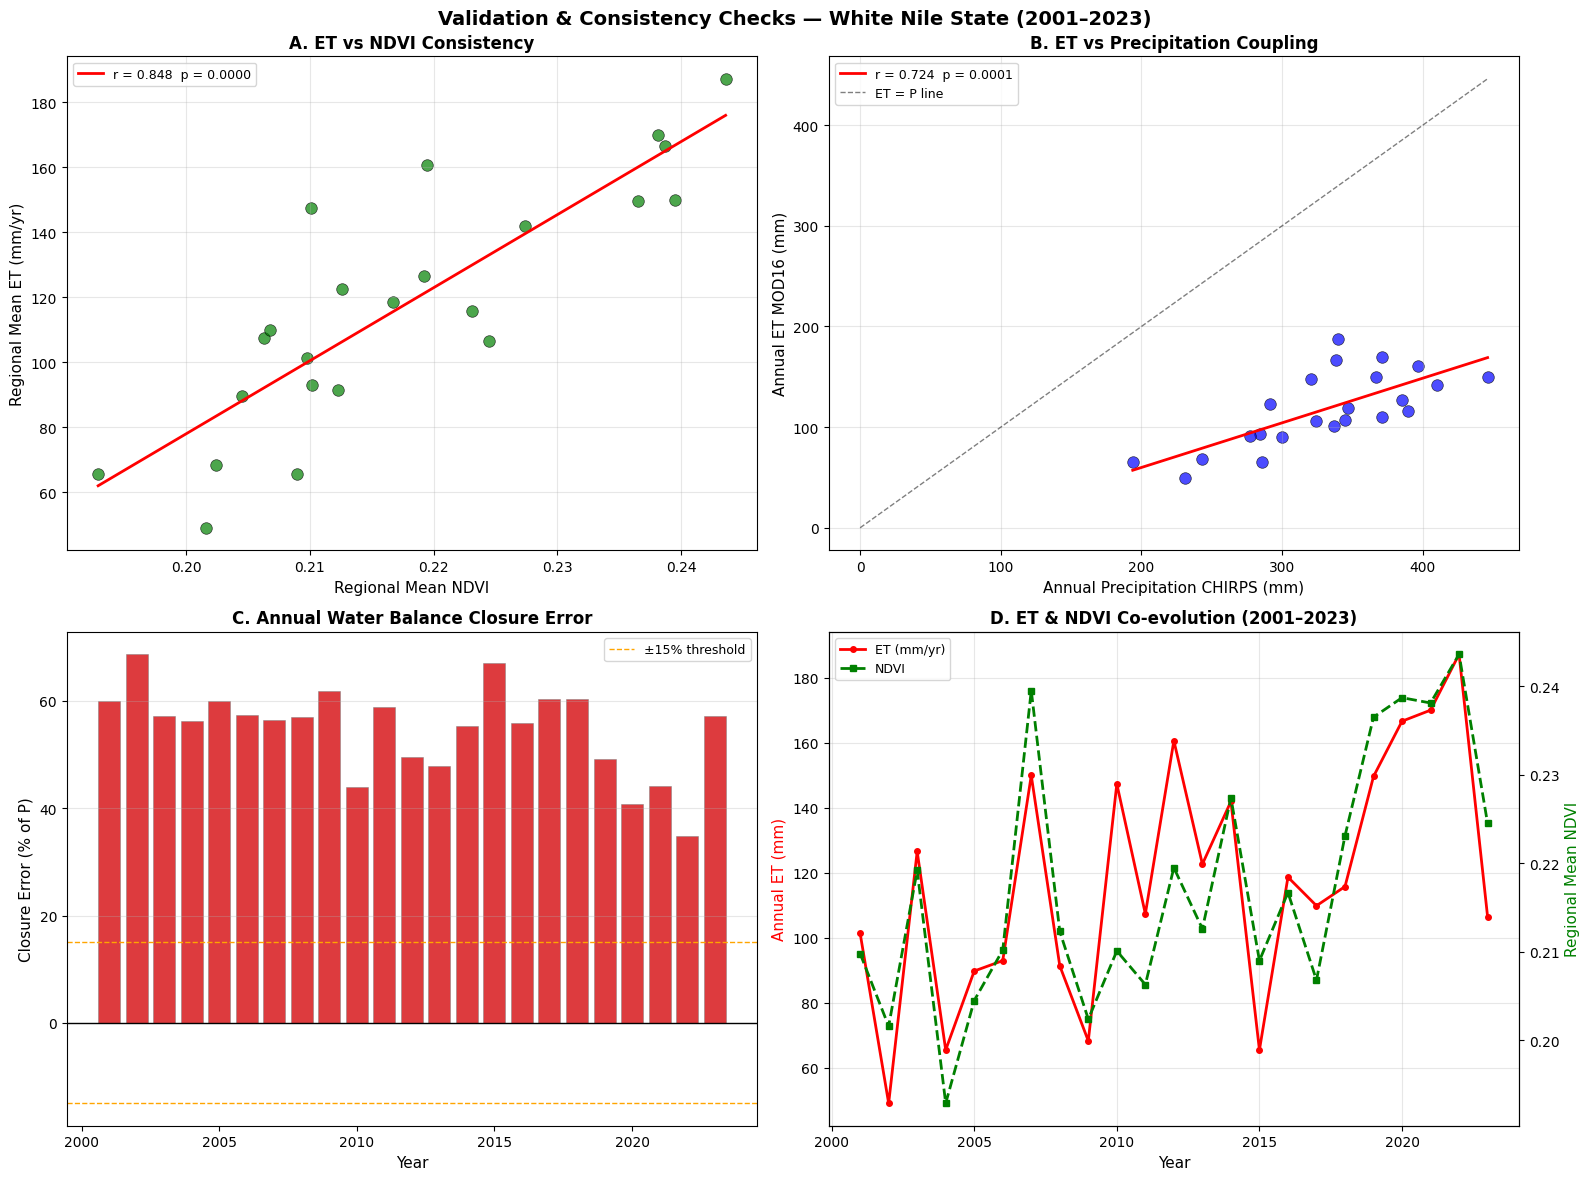

💾 Saved: /content/drive/MyDrive/ET_WhiteNile_Analysis/plots/F5_Validation_Dashboard.png

  NOTEBOOK 5 COMPLETED SUCCESSFULLY

  Outputs generated:
    - Table: /content/drive/MyDrive/ET_WhiteNile_Analysis/tables/T8_Validation_NDVI_WaterBalance.csv
    - Figure: /content/drive/MyDrive/ET_WhiteNile_Analysis/plots/F5_Validation_Dashboard.png

  Key metrics:
    ET-NDVI correlation: r = 0.848
    Water balance closure error: 54.8%


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║           NOTEBOOK 5 — VALIDATION & CROSS-PRODUCT COMPARISON               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Paste this block into Cell 6 of your Colab notebook.
# This cell is FULLY SELF-CONTAINED — safe to run after kernel restart.

# ── 5.0  Guaranteed session bootstrap ────────────────────────────────────────
import ee
import os
import json
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")

# Initialize Earth Engine
try:
    ee.Initialize(project='evapotranspiration-495110') # Added project ID
    print("✅ GEE initialized")
except Exception as e:
    print(f"⚠️ GEE init failed: {e}")
    ee.Authenticate()
    ee.Initialize(project='evapotranspiration-495110') # Added project ID

# -- Core constants -----------------------------------------------------------
START_YEAR = 2001
END_YEAR = 2023
START_DATE = f"{START_YEAR}-01-01"
END_DATE = f"{END_YEAR}-12-31"
years = list(range(START_YEAR, END_YEAR + 1))

# Set output directory (adjust if different)
OUTPUT_DIR = "/content/drive/MyDrive/ET_WhiteNile_Analysis"
os.makedirs(f"{OUTPUT_DIR}/tables", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)

print(f"✅ Output directory: {OUTPUT_DIR}")

# -- AOI geometry (reload from sources) ---------------------------------------
aoi_geometry = None
AOI_SOURCE = None

print("\n🔍 Loading Area of Interest...")

# Priority 1: Check if aoi_geometry exists in session
try:
    _ = aoi_geometry.getInfo()
    AOI_SOURCE = "session variable"
    print(f"✅ aoi_geometry: already in session")
except (NameError, Exception):
    # Priority 2: GEE personal asset
    try:
        GEE_ASSET = 'projects/ee-abdoyanes2016/assets/White_NILe_State'
        AOI = ee.FeatureCollection(GEE_ASSET)
        aoi_geometry = AOI.geometry()
        aoi_geometry.bounds().getInfo()
        AOI_SOURCE = f"GEE asset: {GEE_ASSET}"
        print(f"✅ aoi_geometry: loaded from GEE asset")
    except Exception as e1:
        print(f"⚠️ GEE asset failed ({e1})")

        # Priority 3: Shapefile on disk
        shp_paths = (glob.glob("/tmp/*/s_area.shp") +
                     glob.glob("/tmp/s_area.shp") +
                     glob.glob("/content/s_area.shp") +
                     glob.glob("/content/drive/MyDrive/**/s_area.shp", recursive=True))

        if shp_paths:
            try:
                import geopandas as gpd
                gdf = gpd.read_file(shp_paths[0]).to_crs("EPSG:4326")
                AOI = ee.FeatureCollection(json.loads(gdf.to_json()))
                aoi_geometry = AOI.geometry()
                AOI_SOURCE = f"shapefile: {shp_paths[0]}"
                print(f"✅ aoi_geometry: loaded from shapefile")
            except Exception as e2:
                print(f"⚠️ Shapefile load failed ({e2})")

        # Priority 4: FAO GAUL fallback
        if aoi_geometry is None:
            try:
                gaul = ee.FeatureCollection("FAO/GAUL/2015/level1")
                AOI = gaul.filter(ee.Filter.And(
                    ee.Filter.eq("ADM0_NAME", "Sudan"),
                    ee.Filter.eq("ADM1_NAME", "White Nile")))
                aoi_geometry = AOI.geometry()
                AOI_SOURCE = "FAO GAUL fallback"
                print(f"✅ aoi_geometry: loaded from FAO GAUL")
            except Exception as e3:
                print(f"❌ All AOI sources failed: {e3}")
                raise

print(f"   Source: {AOI_SOURCE}")

# Get bounds for confirmation
try:
    bounds = aoi_geometry.bounds().getInfo()
    print(f"   Bounds: {bounds['coordinates']}")
except:
    pass

# -- Load MOD16 ET collection (reload if needed) -----------------------------
print("\n🔍 Loading MOD16A2 ET data...")

def qc_scale_MOD16(img):
    """Apply QC mask and scale factor to MOD16A2GF."""
    qc = img.select("ET_QC")
    ok = qc.bitwiseAnd(3).lte(1)  # good + acceptable quality
    et = img.select("ET").multiply(0.1).updateMask(ok).rename("ET_mm")
    pet = img.select("PET").multiply(0.1).updateMask(ok).rename("PET_mm")
    ef = et.divide(pet).rename("EF")
    return (img.addBands(et)
               .addBands(pet)
               .addBands(ef)
               .copyProperties(img, ["system:time_start"]))

MOD16_col = (ee.ImageCollection("MODIS/061/MOD16A2GF")
               .filterDate(START_DATE, END_DATE)
               .filterBounds(aoi_geometry)
               .map(qc_scale_MOD16))

print(f"✅ MOD16 images: {MOD16_col.size().getInfo()}")

# -- Load or compute annual water balance time series -------------------------
print("\n🔍 Loading/computing water balance time series...")

# Try to load from saved CSV
wb_csv_path = f"{OUTPUT_DIR}/tables/T7_Annual_WaterBalance_TimeSeries.csv"

if os.path.exists(wb_csv_path):
    df_wb_ts = pd.read_csv(wb_csv_path)
    print(f"✅ Loaded T7 from CSV: {len(df_wb_ts)} rows")
else:
    print("⚠️ T7 CSV not found. Computing from GEE...")
    wb_rows = []

    for yr in years:
        print(f"  Processing {yr}...")

        # Annual ET
        et_img = (MOD16_col
                  .filter(ee.Filter.calendarRange(yr, yr, "year"))
                  .select("ET_mm")
                  .mean()
                  .multiply(46))

        et_val = et_img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi_geometry,
            scale=1000,
            maxPixels=1e10,
            bestEffort=True
        ).getInfo()

        # Annual Precipitation from CHIRPS
        chirps = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
                  .filterDate(f"{yr}-01-01", f"{yr}-12-31")
                  .filterBounds(aoi_geometry)
                  .sum())

        p_val = chirps.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi_geometry,
            scale=5000,
            maxPixels=1e10,
            bestEffort=True
        ).getInfo()

        wb_rows.append({
            "Year": yr,
            "ET_mm": round(et_val.get("ET_mm", 0) or 0, 1),
            "Precip_mm": round(p_val.get("precipitation", 0) or 0, 1)
        })

    df_wb_ts = pd.DataFrame(wb_rows)
    df_wb_ts["P_minus_ET"] = df_wb_ts["Precip_mm"] - df_wb_ts["ET_mm"]
    df_wb_ts["ET_P_ratio"] = (df_wb_ts["ET_mm"] / df_wb_ts["Precip_mm"].replace(0, np.nan)).round(3)

    # Save for future use
    os.makedirs(f"{OUTPUT_DIR}/tables", exist_ok=True)
    df_wb_ts.to_csv(wb_csv_path, index=False)
    print(f"✅ Computed and saved T7: {len(df_wb_ts)} rows")

print(df_wb_ts.head())

# ── 5.1  NDVI–ET Consistency Check (MOD13A2) ─────────────────────────────────
print("\n🔬 Running NDVI-ET consistency check...")

# Load MOD13A2 NDVI collection
NDVI_col = (ee.ImageCollection("MODIS/061/MOD13A2")
            .filterDate(START_DATE, END_DATE)
            .filterBounds(aoi_geometry)
            .select("NDVI")
            .map(lambda img: (img.multiply(0.0001)
                              .copyProperties(img, ["system:time_start"]))))

# Annual mean NDVI per year
ndvi_ts_rows = []
for year in years:
    print(f"  Computing NDVI for {year}...")
    try:
        ndvi_yr = (NDVI_col
                   .filter(ee.Filter.calendarRange(year, year, "year"))
                   .mean()
                   .reduceRegion(
                       reducer=ee.Reducer.mean(),
                       geometry=aoi_geometry,
                       scale=1000,
                       maxPixels=1e10,
                       bestEffort=True
                   ).getInfo())

        ndvi_val = ndvi_yr.get("NDVI", 0) or 0
        ndvi_ts_rows.append({"Year": year, "NDVI": round(ndvi_val, 4)})
        print(f"    NDVI = {ndvi_val:.4f}")
    except Exception as e:
        print(f"    Failed for {year}: {e}")
        ndvi_ts_rows.append({"Year": year, "NDVI": np.nan})

df_ndvi_ts = pd.DataFrame(ndvi_ts_rows)
print(f"✅ NDVI time series: {len(df_ndvi_ts)} rows")

# Merge with water balance data
df_valid = df_wb_ts.merge(df_ndvi_ts, on="Year")

# Pearson correlation: ET vs NDVI
valid_mask = df_valid["ET_mm"].notna() & df_valid["NDVI"].notna()
if valid_mask.sum() >= 3:
    r_et_ndvi, p_et_ndvi = stats.pearsonr(
        df_valid.loc[valid_mask, "ET_mm"],
        df_valid.loc[valid_mask, "NDVI"]
    )
else:
    r_et_ndvi, p_et_ndvi = np.nan, np.nan
    print("⚠️ Insufficient valid data for correlation")

print(f"\n🔬 ET–NDVI Correlation (regional annual means):")
print(f"   Pearson r = {r_et_ndvi:.3f} | p = {p_et_ndvi:.4f}" if not np.isnan(r_et_ndvi) else "   ❌ Correlation not available")

if not np.isnan(r_et_ndvi):
    if r_et_ndvi > 0.6 and p_et_ndvi < 0.05:
        print("   ✅ Strong positive ET–NDVI coupling — product is physically consistent")
    elif r_et_ndvi > 0.3:
        print("   ⚠️ Moderate ET–NDVI coupling — check cloud contamination in wet season")
    else:
        print("   ❌ Weak ET–NDVI correlation — check LULC classification or QC filtering")

# ── 5.2  Water Balance Closure Check ─────────────────────────────────────────
print("\n🔬 Water Balance Closure Check (P – ET = ΔS + Q):")
print("   Q ≈ 10% of P (semi-arid Sudan estimate) | ΔS ≈ 0 (long-term mean)")

if df_wb_ts.empty or "Precip_mm" not in df_wb_ts.columns:
    print("   ⚠️ Skipped — water balance data not available")
    mean_closure_err = np.nan
else:
    df_valid["Q_approx_mm"] = df_valid["Precip_mm"] * 0.10
    df_valid["Closure_Error_mm"] = (df_valid["Precip_mm"]
                                     - df_valid["ET_mm"]
                                     - df_valid["Q_approx_mm"])
    df_valid["Closure_Error_pct"] = (
        df_valid["Closure_Error_mm"]
        / df_valid["Precip_mm"].replace(0, np.nan) * 100
    ).round(1)

    mean_closure_err = df_valid["Closure_Error_pct"].abs().mean()
    print(f"   Mean absolute closure error: {mean_closure_err:.1f}%")
    if mean_closure_err < 15:
        print("   ✅ Acceptable closure (<15%) — water balance internally consistent")
    elif mean_closure_err < 30:
        print("   ⚠️ Moderate closure error (15–30%) — review Q estimate or ET bias")
    else:
        print("   ❌ Large closure error (>30%) — investigate data quality")

# Save validation table
df_valid.to_csv(f"{OUTPUT_DIR}/tables/T8_Validation_NDVI_WaterBalance.csv", index=False)
print(f"\n💾 Saved: {OUTPUT_DIR}/tables/T8_Validation_NDVI_WaterBalance.csv")

# ── 5.3  FIGURE 5: Validation Dashboard ──────────────────────────────────────
print("\n📊 Generating Figure 5: Validation Dashboard...")

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Validation & Consistency Checks — White Nile State (2001–2023)",
    fontsize=14, fontweight="bold"
)

# Panel A: ET vs NDVI scatter
ax = axes[0, 0]
if valid_mask.sum() >= 3:
    ax.scatter(df_valid.loc[valid_mask, "NDVI"],
               df_valid.loc[valid_mask, "ET_mm"],
               color="green", alpha=0.7, s=70, edgecolors="k", linewidths=0.5)

    if not np.isnan(r_et_ndvi):
        _m, _b = np.polyfit(df_valid.loc[valid_mask, "NDVI"],
                            df_valid.loc[valid_mask, "ET_mm"], 1)
        _x = np.linspace(df_valid.loc[valid_mask, "NDVI"].min(),
                         df_valid.loc[valid_mask, "NDVI"].max(), 50)
        ax.plot(_x, _m * _x + _b, "r-", linewidth=2,
                label=f"r = {r_et_ndvi:.3f}  p = {p_et_ndvi:.4f}")
    ax.set_xlabel("Regional Mean NDVI", fontsize=11)
    ax.set_ylabel("Regional Mean ET (mm/yr)", fontsize=11)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "Insufficient data\nfor correlation",
            ha="center", va="center", transform=ax.transAxes)
ax.set_title("A. ET vs NDVI Consistency", fontweight="bold")
ax.grid(alpha=0.3)

# Panel B: ET vs Precipitation scatter
ax = axes[0, 1]
if "Precip_mm" in df_valid.columns and len(df_valid) > 1:
    p_valid = df_valid["Precip_mm"].notna() & df_valid["ET_mm"].notna()
    if p_valid.sum() >= 3:
        _r_p, _p_p = stats.pearsonr(df_valid.loc[p_valid, "Precip_mm"],
                                     df_valid.loc[p_valid, "ET_mm"])
        ax.scatter(df_valid.loc[p_valid, "Precip_mm"],
                   df_valid.loc[p_valid, "ET_mm"],
                   color="blue", alpha=0.7, s=70, edgecolors="k", linewidths=0.5)
        _m2, _b2 = np.polyfit(df_valid.loc[p_valid, "Precip_mm"],
                               df_valid.loc[p_valid, "ET_mm"], 1)
        _x2 = np.linspace(df_valid.loc[p_valid, "Precip_mm"].min(),
                          df_valid.loc[p_valid, "Precip_mm"].max(), 50)
        ax.plot(_x2, _m2 * _x2 + _b2, "r-", linewidth=2,
                label=f"r = {_r_p:.3f}  p = {_p_p:.4f}")
        _mx = max(df_valid.loc[p_valid, "Precip_mm"].max(),
                  df_valid.loc[p_valid, "ET_mm"].max())
        ax.plot([0, _mx], [0, _mx], "k--", linewidth=1, alpha=0.5, label="ET = P line")
        ax.legend(fontsize=9)
ax.set_xlabel("Annual Precipitation CHIRPS (mm)", fontsize=11)
ax.set_ylabel("Annual ET MOD16 (mm)", fontsize=11)
ax.set_title("B. ET vs Precipitation Coupling", fontweight="bold")
ax.grid(alpha=0.3)

# Panel C: Water balance closure error bar chart
ax = axes[1, 0]
if "Closure_Error_pct" in df_valid.columns and len(df_valid) > 0:
    _cols = ["#2b83ba" if abs(v) < 15 else "#fdae61" if abs(v) < 30 else "#d7191c"
             for v in df_valid["Closure_Error_pct"].fillna(0)]
    ax.bar(df_valid["Year"], df_valid["Closure_Error_pct"].fillna(0),
           color=_cols, alpha=0.85, edgecolor="grey", linewidth=0.4)
    ax.axhline(0, color="black", linewidth=1)
    ax.axhline(15, color="orange", linewidth=1, linestyle="--", label="±15% threshold")
    ax.axhline(-15, color="orange", linewidth=1, linestyle="--")
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Closure Error (% of P)", fontsize=11)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No closure data available",
            ha="center", va="center", transform=ax.transAxes, color="grey")
ax.set_title("C. Annual Water Balance Closure Error", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# Panel D: ET & NDVI dual-axis time series
ax = axes[1, 1]
ax2 = ax.twinx()

if len(df_valid) > 0:
    l1, = ax.plot(df_valid["Year"], df_valid["ET_mm"],
                  "r-o", markersize=4, linewidth=2, label="ET (mm/yr)")

    ndvi_plot = df_valid["NDVI"].fillna(0)
    l2, = ax2.plot(df_valid["Year"], ndvi_plot,
                   "g--s", markersize=4, linewidth=2, label="NDVI")

    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Annual ET (mm)", fontsize=11, color="red")
    ax2.set_ylabel("Regional Mean NDVI", fontsize=11, color="green")
    ax.legend(handles=[l1, l2], fontsize=9, loc="upper left")
else:
    ax.text(0.5, 0.5, "No time series data available",
            ha="center", va="center", transform=ax.transAxes)
ax.set_title("D. ET & NDVI Co-evolution (2001–2023)", fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/F5_Validation_Dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {OUTPUT_DIR}/plots/F5_Validation_Dashboard.png")

# ── 5.4  Summary output ──────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  NOTEBOOK 5 COMPLETED SUCCESSFULLY")
print("=" * 70)
print(f"\n  Outputs generated:")
print(f"    - Table: {OUTPUT_DIR}/tables/T8_Validation_NDVI_WaterBalance.csv")
print(f"    - Figure: {OUTPUT_DIR}/plots/F5_Validation_Dashboard.png")
print(f"\n  Key metrics:")
if not np.isnan(r_et_ndvi):
    print(f"    ET-NDVI correlation: r = {r_et_ndvi:.3f}")
if not np.isnan(mean_closure_err):
    print(f"    Water balance closure error: {mean_closure_err:.1f}%")
print("=" * 70)